<a href="https://colab.research.google.com/github/LamaAlarfaj/tabular-synthetic-generation/blob/main/data_tabular_reordered.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Saai Synthetic Data — Tabular Data (CTGAN + Mixed Data)

---

## Welcome to Saai (ساعي)

**Saai** is Saudi Arabia's first Arabic-first, high-quality AI & Data Science education platform. Our mission is to teach **practical, deep understanding** — not shallow tool usage — using real workflows and strong storytelling.

### What You'll Learn Today

In this notebook, you'll master **synthetic data generation for tabular datasets**:

1. ✅ **Understand tabular distributions** — how real data is structured
2. ✅ **Train CTGAN** — a powerful generative model for mixed data types
3. ✅ **Generate realistic synthetic data** — create privacy-preserving alternatives
4. ✅ **Evaluate quality** — assess fidelity, utility, and privacy
5. ✅ **Handle mixed structured + text data** — real-world datasets aren't purely numeric

### Course Structure

**Case 1:** Pure Tabular (Insurance Dataset)  
Classic synthetic data generation with mixed numerical and categorical columns.

**Case 2:** Tabular + Text (Real Estate Dataset)  
Realistic scenario with structured columns plus Arabic text descriptions.

---

Let's begin! 🚀

---
## 1. Setup & Imports

### Installation Notes

Before running this notebook, ensure you have the required libraries:

```bash
pip install ctgan sdv scikit-learn matplotlib seaborn pandas numpy
```

### Import Libraries

In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# Scikit-learn for preprocessing and modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# CTGAN for synthetic data generation
from ctgan import CTGAN

# SDV for baseline (optional)
try:
    from sdv.single_table import GaussianCopulaSynthesizer
    from sdv.metadata import SingleTableMetadata
    SDV_AVAILABLE = True
except ImportError:
    print("⚠️ SDV not installed. Skipping GaussianCopula baseline.")
    SDV_AVAILABLE = False

# Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("✅ All libraries imported successfully!")
print(f"📦 NumPy version: {np.__version__}")
print(f"📦 Pandas version: {pd.__version__}")

✅ All libraries imported successfully!
📦 NumPy version: 2.2.6
📦 Pandas version: 2.3.3


### Utility Helper Functions

These reusable functions will help us throughout the notebook.

In [ ]:
def dataset_summary(df, name="Dataset"):
    """
    Print a comprehensive summary of the dataset.
    """
    print(f"\n{'='*60}")
    print(f"📊 {name} Summary")
    print(f"{'='*60}")
    print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"\nColumns: {list(df.columns)}")
    print(f"\nData Types:")
    print(df.dtypes)
    print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print(f"{'='*60}\n")


def column_dictionary(df):
    """
    Create a data dictionary showing column details.
    """
    data_dict = []
    for col in df.columns:
        dtype = str(df[col].dtype)
        missing = df[col].isna().sum()
        missing_pct = (missing / len(df)) * 100

        # Sample values
        if df[col].dtype in ['object', 'category']:
            unique_count = df[col].nunique()
            sample_vals = df[col].dropna().unique()[:3].tolist()
        else:
            unique_count = df[col].nunique()
            sample_vals = df[col].dropna().iloc[:3].tolist()

        data_dict.append({
            'Column': col,
            'Type': dtype,
            'Unique': unique_count,
            'Missing': f"{missing} ({missing_pct:.1f}%)",
            'Sample Values': str(sample_vals)[:50]
        })

    return pd.DataFrame(data_dict)


def plot_numeric_distributions(df, columns, bins=30, figsize=(15, 4)):
    """
    Plot histograms for numeric columns.
    """
    n_cols = len(columns)
    fig, axes = plt.subplots(1, n_cols, figsize=figsize)

    if n_cols == 1:
        axes = [axes]

    for idx, col in enumerate(columns):
        axes[idx].hist(df[col].dropna(), bins=bins, alpha=0.7, edgecolor='black')
        axes[idx].set_title(f'{col} Distribution', fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_categorical_distributions(df, columns, top_k=10, figsize=(15, 4)):
    """
    Plot bar charts for categorical columns.
    """
    n_cols = len(columns)
    fig, axes = plt.subplots(1, n_cols, figsize=figsize)

    if n_cols == 1:
        axes = [axes]

    for idx, col in enumerate(columns):
        value_counts = df[col].value_counts().head(top_k)
        axes[idx].bar(range(len(value_counts)), value_counts.values, alpha=0.7)
        axes[idx].set_title(f'{col} Distribution', fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Count')
        axes[idx].set_xticks(range(len(value_counts)))
        axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
        axes[idx].grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()


def compare_distributions(real_df, synth_df, column, column_type='numeric', bins=30):
    """
    Compare real vs synthetic distributions side-by-side.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    if column_type == 'numeric':
        axes[0].hist(real_df[column].dropna(), bins=bins, alpha=0.7, color='blue', edgecolor='black')
        axes[0].set_title(f'Real Data: {column}', fontweight='bold')
        axes[0].set_xlabel(column)
        axes[0].set_ylabel('Frequency')

        axes[1].hist(synth_df[column].dropna(), bins=bins, alpha=0.7, color='orange', edgecolor='black')
        axes[1].set_title(f'Synthetic Data: {column}', fontweight='bold')
        axes[1].set_xlabel(column)
        axes[1].set_ylabel('Frequency')
    else:
        real_counts = real_df[column].value_counts().head(10)
        synth_counts = synth_df[column].value_counts().head(10)

        axes[0].bar(range(len(real_counts)), real_counts.values, alpha=0.7, color='blue')
        axes[0].set_title(f'Real Data: {column}', fontweight='bold')
        axes[0].set_xticks(range(len(real_counts)))
        axes[0].set_xticklabels(real_counts.index, rotation=45, ha='right')
        axes[0].set_ylabel('Count')

        axes[1].bar(range(len(synth_counts)), synth_counts.values, alpha=0.7, color='orange')
        axes[1].set_title(f'Synthetic Data: {column}', fontweight='bold')
        axes[1].set_xticks(range(len(synth_counts)))
        axes[1].set_xticklabels(synth_counts.index, rotation=45, ha='right')
        axes[1].set_ylabel('Count')

    plt.tight_layout()
    plt.show()


def plot_correlation_heatmap(df, title="Correlation Heatmap", figsize=(10, 8)):
    """
    Plot correlation heatmap for numeric columns.
    """
    numeric_df = df.select_dtypes(include=[np.number])
    corr = numeric_df.corr()

    plt.figure(figsize=figsize)
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title(title, fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()


def sanity_checks(df, name="Dataset"):
    """
    Run quick sanity checks on the dataset.
    """
    print(f"\n🔍 Sanity Checks for {name}")
    print(f"{'-'*50}")

    # Duplicates
    dup_count = df.duplicated().sum()
    print(f"Duplicate rows: {dup_count} ({(dup_count/len(df)*100):.2f}%)")

    # Missing values
    missing = df.isna().sum().sum()
    print(f"Missing values: {missing} ({(missing/df.size*100):.2f}%)")

    # Numeric ranges
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        print(f"\nNumeric columns range check:")
        for col in numeric_cols:
            print(f"  {col}: [{df[col].min():.2f}, {df[col].max():.2f}]")

    print(f"{'-'*50}\n")


print("✅ Utility functions loaded!")

✅ Utility functions loaded!


---
## 2. Synthetic Data Primer

Before diving into code, let's understand what we're building.

### What is Synthetic Data?

**Synthetic data** is artificially generated data that mimics the statistical properties of real data, but doesn't contain actual observations from the original dataset.

Think of it like this:
- **Real data**: Actual patient records from a hospital
- **Synthetic data**: Computer-generated "patients" that look realistic but aren't real people

### When Does Synthetic Data Help?

1. **Privacy Protection** — Share data without exposing individuals (e.g., medical records, financial data)
2. **Data Scarcity** — Generate more samples when real data is limited (e.g., rare diseases)
3. **Handling Imbalance** — Create more minority class examples for better model training
4. **Sharing Constraints** — Bypass legal/contractual restrictions on sharing real data

### Key Risks to Watch Out For

⚠️ **Memorization/Leakage**: The model might just copy real records  
⚠️ **Unrealistic Distributions**: Synthetic data might not match real patterns  
⚠️ **Bias Amplification**: Existing biases can be magnified in synthetic data  

### Three Evaluation Axes

We'll evaluate synthetic data on three dimensions:

#### (A) Fidelity — "Does it look real?"
- Do distributions match?
- Are correlations preserved?
- Are value ranges realistic?

#### (B) Utility — "Does it still work for modeling?"
- Can we train models on synthetic data?
- Do models perform similarly on real test data?
- Are the learned patterns transferable?

#### (C) Privacy — "Does it protect individuals?"
- Can we re-identify people?
- Are exact records copied?
- Is sensitive information leaked?

> **Why This Matters**: Understanding these trade-offs is crucial. Maximizing one dimension might hurt another. For example, perfect fidelity could mean poor privacy (exact copying).

---

Now let's see this in action!

---
# CASE 1: Pure Tabular Dataset (Insurance)

We'll start with a classic tabular dataset containing insurance information with mixed numeric and categorical columns.

---

## 3.1 Load Data

In [ ]:
# Dataset path
DATA_PATH_CASE1 = "/home/insurance.csv"
# Load data
df_insurance = pd.read_csv(DATA_PATH_CASE1)

print("✅ Data loaded successfully!\n")

# Display basic info
dataset_summary(df_insurance, "Insurance Dataset")

# Preview
print("First 5 rows:")
display(df_insurance.head())

print("\nLast 5 rows:")
display(df_insurance.tail())

✅ Data loaded successfully!


📊 Insurance Dataset Summary
Shape: 1,338 rows × 7 columns

Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Data Types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Memory Usage: 0.28 MB

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



Last 5 rows:


,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [ ]:
# Create column dictionary
print("📖 Column Dictionary:\n")
col_dict = column_dictionary(df_insurance)
display(col_dict)

📖 Column Dictionary:



,Column,Type,Unique,Missing,Sample Values
0,age,int64,47,0 (0.0%),"[19, 18, 28]"
1,sex,object,2,0 (0.0%),"['female', 'male']"
2,bmi,float64,548,0 (0.0%),"[27.9, 33.77, 33.0]"
3,children,int64,6,0 (0.0%),"[0, 1, 3]"
4,smoker,object,2,0 (0.0%),"['yes', 'no']"
5,region,object,4,0 (0.0%),"['southwest', 'southeast', 'northwest']"
6,charges,float64,1337,0 (0.0%),"[16884.924, 1725.5523, 4449.462]"


### What We See

The dataset contains:
- **Numeric columns**: age, bmi, children, charges
- **Categorical columns**: sex, smoker, region
- **No missing values** (clean dataset)

**Target variable**: `charges` (medical insurance costs) — this will be our prediction target for utility evaluation.

---

## 3.2 Exploratory Data Analysis (EDA)

Before generating synthetic data, we must **deeply understand** the real data's structure and patterns.

In [ ]:
# Missing values check
print("🔍 Missing Values Check:\n")
missing = df_insurance.isna().sum()
if missing.sum() == 0:
    print("✅ No missing values found!")
else:
    display(missing[missing > 0])

🔍 Missing Values Check:

✅ No missing values found!


In [ ]:
# Numeric summary
print("📊 Numeric Columns Summary:\n")
display(df_insurance.describe())

📊 Numeric Columns Summary:



,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Key Observations (Numeric):

- **Age**: Ranges from 18 to 64, mean ~39 years
- **BMI**: Mean ~30.6 (slightly overweight by medical standards)
- **Children**: 0-5 children, mean ~1
- **Charges**: Highly variable ($1,121 to $63,770), right-skewed distribution (mean > median)

> **Why This Matters**: CTGAN needs to learn these ranges and distributions. If synthetic data has impossible values (e.g., negative age), it's not useful.

In [ ]:
# Categorical summary
print("📊 Categorical Columns Summary:\n")

for col in ['sex', 'smoker', 'region']:
    print(f"\n{col.upper()}:")
    value_counts = df_insurance[col].value_counts()
    print(value_counts)
    print(f"Proportions:")
    print(df_insurance[col].value_counts(normalize=True).round(3))

📊 Categorical Columns Summary:


SEX:
sex
male      676
female    662
Name: count, dtype: int64
Proportions:
sex
male      0.505
female    0.495
Name: proportion, dtype: float64

SMOKER:
smoker
no     1064
yes     274
Name: count, dtype: int64
Proportions:
smoker
no     0.795
yes    0.205
Name: proportion, dtype: float64

REGION:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
Proportions:
region
southeast    0.272
southwest    0.243
northwest    0.243
northeast    0.242
Name: proportion, dtype: float64


### Key Observations (Categorical):

- **Sex**: Balanced (~50/50 split)
- **Smoker**: Imbalanced (~20% smokers, 80% non-smokers)
- **Region**: 4 regions, relatively balanced

> **Why This Matters**: CTGAN must preserve these proportions. If synthetic data has 50% smokers instead of 20%, it's not realistic.

📈 Numeric Distributions:



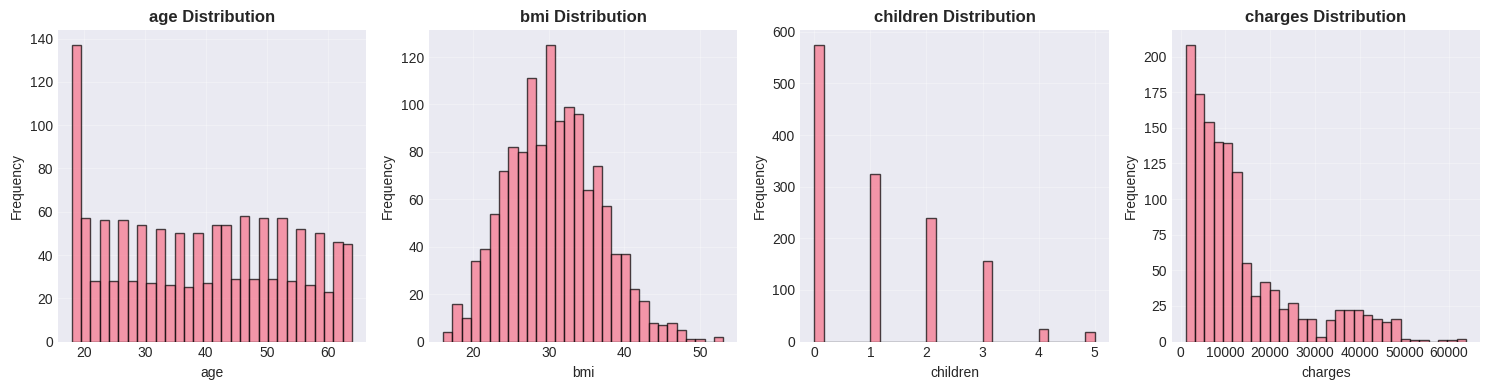

In [ ]:
# Visualize numeric distributions
print("📈 Numeric Distributions:\n")
plot_numeric_distributions(df_insurance, ['age', 'bmi', 'children', 'charges'])

### Distribution Insights:

- **Age**: Relatively uniform distribution
- **BMI**: Roughly normal distribution (bell curve)
- **Children**: Discrete, concentrated at 0-2
- **Charges**: Heavily right-skewed (long tail on the right) — most people have lower charges, few have very high charges

📊 Categorical Distributions:



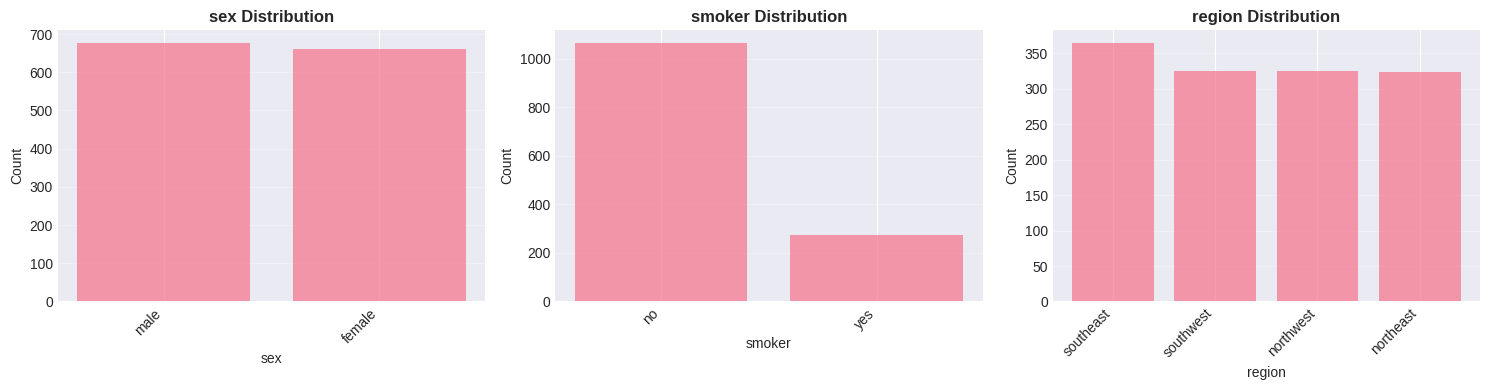

In [ ]:
# Visualize categorical distributions
print("📊 Categorical Distributions:\n")
plot_categorical_distributions(df_insurance, ['sex', 'smoker', 'region'])

🔗 Correlation Heatmap (Numeric Columns):



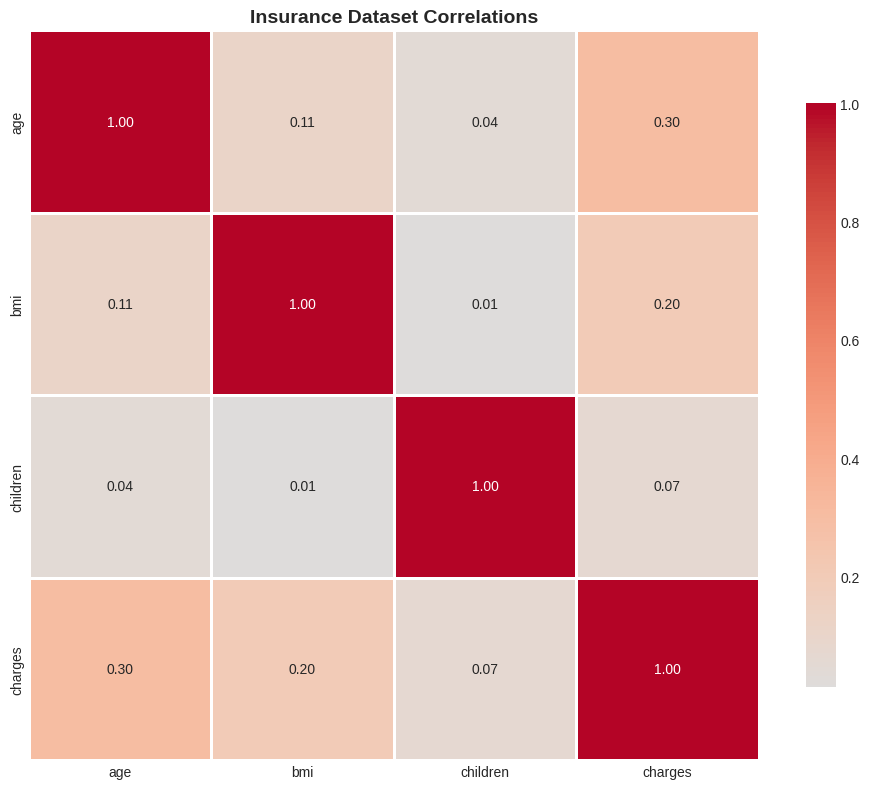

In [ ]:
# Correlation analysis
print("🔗 Correlation Heatmap (Numeric Columns):\n")
plot_correlation_heatmap(df_insurance, title="Insurance Dataset Correlations")

### Correlation Insights:

- **Age vs Charges**: Moderate positive correlation (older → higher charges)
- **BMI vs Charges**: Weak positive correlation
- **Children vs Charges**: Very weak correlation

> **Why This Matters**: CTGAN must learn these relationships. If age and charges become uncorrelated in synthetic data, the data isn't realistic.

---

## 3.3 Define the Modeling Goal (Utility Task)

To evaluate **utility**, we need a supervised learning task. We'll predict `charges` (regression problem).

### Why Define a Modeling Goal?

Synthetic data is only useful if it **works for downstream tasks**. We'll:
1. Train a model on **real data** → baseline performance
2. Train on **synthetic data** → test if it preserves learnable patterns

This is our "utility anchor."

In [ ]:
# Define features and target
X = df_insurance.drop('charges', axis=1)
y = df_insurance['charges']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures: {list(X.columns)}")
print(f"Target: charges (medical insurance costs)")

Features shape: (1338, 6)
Target shape: (1338,)

Features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
Target: charges (medical insurance costs)


In [ ]:
# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 1070 samples
Test set: 268 samples


In [ ]:
# Build preprocessing pipeline
# Identify categorical and numeric columns
categorical_cols = ['sex', 'smoker', 'region']
numeric_cols = ['age', 'bmi', 'children']

print(f"Categorical columns: {categorical_cols}")
print(f"Numeric columns: {numeric_cols}")

# Create preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ]
)

# Create baseline model
baseline_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1))
])

print("\n✅ Preprocessing pipeline created!")

Categorical columns: ['sex', 'smoker', 'region']
Numeric columns: ['age', 'bmi', 'children']

✅ Preprocessing pipeline created!


In [ ]:
# Train baseline model on REAL data
print("🎯 Training baseline model on REAL data...\n")

baseline_model.fit(X_train, y_train)

# Predict on test set
y_pred = baseline_model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("📊 Baseline Performance (Real Data):")
print(f"{'='*50}")
print(f"R² Score: {r2:.4f}")
print(f"MAE: ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"{'='*50}")

# Store baseline metrics for comparison
baseline_metrics = {
    'r2': r2,
    'mae': mae,
    'rmse': rmse
}

print("\n✅ Baseline established! We'll compare synthetic data performance against these metrics.")

🎯 Training baseline model on REAL data...

📊 Baseline Performance (Real Data):
R² Score: 0.8656
MAE: $2,543.98
RMSE: $4,567.78

✅ Baseline established! We'll compare synthetic data performance against these metrics.


### Baseline Interpretation:

- **R² Score**: Measures how much variance our model explains (1.0 = perfect, 0.0 = useless)
- **MAE**: Average prediction error in dollars
- **RMSE**: Root mean squared error (penalizes large errors more)

**This is our utility anchor.** When we train on synthetic data, we'll compare against these numbers.

---

## 3.4 CTGAN — Step-by-Step

### What is CTGAN?

**CTGAN** (Conditional Tabular GAN) is a specialized generative model for tabular data.

#### GAN Basics:
- **Generator**: Creates fake data
- **Discriminator**: Tries to distinguish real from fake
- They compete: Generator gets better at fooling the discriminator

#### Why CTGAN for Tabular Data?
1. **Handles mixed data types** (numeric + categorical)
2. **Mode-specific normalization** for numeric columns
3. **Conditional sampling** to handle imbalanced categories
4. **Training-by-sampling** to ensure all categories are learned

> **Common Mistake**: Using regular GANs (designed for images) on tabular data. They fail because tabular data has different statistical properties (mixed types, correlations, etc.).

Let's train CTGAN!

In [ ]:
# Identify discrete (categorical) columns explicitly
discrete_columns = ['sex', 'smoker', 'region']

print(f"🎯 Discrete columns for CTGAN: {discrete_columns}")
print(f"📊 CTGAN will treat these as categorical and preserve their distributions.\n")

🎯 Discrete columns for CTGAN: ['sex', 'smoker', 'region']
📊 CTGAN will treat these as categorical and preserve their distributions.



In [ ]:
# Initialize CTGAN
ctgan_model = CTGAN(
    epochs=500,  # Number of training iterations (increase for better quality)
    batch_size=500,  # Number of samples per training batch
    verbose=True,  # Show training progress
    cuda=True  # Set to True if you have GPU
)

print("\n📋 CTGAN Configuration:")
print(f"{'='*50}")
print(f"Epochs: 100 (controls training time and quality)")
print(f"Batch Size: 500 (higher = faster but more memory)")
print(f"Discrete Columns: {discrete_columns}")
print(f"{'='*50}\n")

print("💡 Training Tips:")
print("  - More epochs = better quality but slower training")
print("  - Start with 50-100 epochs for experiments")
print("  - Use 300+ epochs for production-quality synthetic data")
print("  - Monitor loss values: they should decrease over time\n")


📋 CTGAN Configuration:
Epochs: 100 (controls training time and quality)
Batch Size: 500 (higher = faster but more memory)
Discrete Columns: ['sex', 'smoker', 'region']

💡 Training Tips:
  - More epochs = better quality but slower training
  - Start with 50-100 epochs for experiments
  - Use 300+ epochs for production-quality synthetic data
  - Monitor loss values: they should decrease over time



In [ ]:
# Train CTGAN
print("🚀 Training CTGAN... This may take a few minutes.\n")
print("Progress: (Loss values should decrease over time)\n")

ctgan_model.fit(df_insurance, discrete_columns=discrete_columns)

print("\n✅ CTGAN training complete!")

🚀 Training CTGAN... This may take a few minutes.

Progress: (Loss values should decrease over time)



Gen. (-1.30) | Discrim. (0.01): 100%|██████████| 500/500 [00:27<00:00, 18.00it/s] 


✅ CTGAN training complete!


### What Just Happened?

CTGAN learned:
1. **Marginal distributions** of each column
2. **Correlations** between columns
3. **Conditional patterns** (e.g., smokers tend to have higher charges)

The loss values you saw represent how well the discriminator distinguishes real from fake. As training progresses, the generator gets better at fooling it.

---

In [ ]:
# Generate synthetic samples
n_samples = len(df_insurance)  # Generate same number as original

print(f"🎲 Generating {n_samples:,} synthetic samples...\n")

df_synthetic = ctgan_model.sample(n_samples)

print(f"✅ Synthetic data generated!\n")
print(f"Shape: {df_synthetic.shape}")
print(f"\nFirst 5 synthetic rows:")
display(df_synthetic.head())

🎲 Generating 1,338 synthetic samples...

✅ Synthetic data generated!

Shape: (1338, 7)

First 5 synthetic rows:


,age,sex,bmi,children,smoker,region,charges
0,29,male,41.758282,2,no,northeast,8844.989409
1,47,female,29.824794,0,no,northeast,5403.019536
2,55,female,26.577932,1,no,northeast,37390.124796
3,16,female,42.852086,2,no,northeast,58149.815779
4,28,female,40.751315,0,no,northeast,12557.562599


In [ ]:
# Sanity checks on synthetic data
sanity_checks(df_synthetic, "Synthetic Insurance Data")


🔍 Sanity Checks for Synthetic Insurance Data
--------------------------------------------------
Duplicate rows: 0 (0.00%)
Missing values: 0 (0.00%)

Numeric columns range check:
  age: [10.00, 73.00]
  bmi: [13.49, 60.88]
  children: [0.00, 6.00]
  charges: [-2878.15, 69224.50]
--------------------------------------------------



In [ ]:
df_synthetic = df_synthetic[~(df_synthetic['charges'] < 0)]
# print(f"After removing negative charges, synthetic data shape: {df_synthetic.shape}\n")# Compare distributions of key columns
# print("🔍 Comparing Distributions:\n")
# for col in ['age', 'bmi', 'children', 'charges', 'sex', 'smoker', 'region']:
#     col_type = 'numeric' if col in ['age', 'bmi', 'children', 'charges'] else 'categorical'
#     compare_distributions(df_insurance, df_synthetic, col, column_type=col_type)
df_synthetic

,age,sex,bmi,children,smoker,region,charges
0,29,male,41.758282,2,no,northeast,8844.989409
1,47,female,29.824794,0,no,northeast,5403.019536
2,55,female,26.577932,1,no,northeast,37390.124796
3,16,female,42.852086,2,no,northeast,58149.815779
4,28,female,40.751315,0,no,northeast,12557.562599
...,...,...,...,...,...,...,...
1333,20,male,34.602914,2,no,southwest,29854.531921
1334,51,male,34.569618,5,no,southeast,16134.297280
1335,30,female,39.767632,1,no,southwest,10323.292115
1336,47,female,30.201744,0,no,northwest,12881.490270


In [ ]:
# print(f"After removing negative charges, synthetic data shape: {df_synthetic.shape}\n")# Compare distributions of key columns
# print("🔍 Comparing Distributions:\n")
# for col in ['age', 'bmi', 'children', 'charges', 'sex', 'smoker', 'region']:
#     col_type = 'numeric' if col in ['age', 'bmi', 'children', 'charges'] else 'categorical'
#     compare_distributions(df_insurance, df_synthetic, col, column_type=col_type)

In [ ]:
# Check for invalid categories
print("🔍 Checking categorical values...\n")

for col in discrete_columns:
    real_categories = set(df_insurance[col].unique())
    synth_categories = set(df_synthetic[col].unique())

    print(f"{col}:")
    print(f"  Real categories: {real_categories}")
    print(f"  Synthetic categories: {synth_categories}")

    invalid = synth_categories - real_categories
    if invalid:
        print(f"  ⚠️ Invalid categories found: {invalid}")
    else:
        print(f"  ✅ All categories valid!")
    print()

🔍 Checking categorical values...

sex:
  Real categories: {'male', 'female'}
  Synthetic categories: {'male', 'female'}
  ✅ All categories valid!

smoker:
  Real categories: {'yes', 'no'}
  Synthetic categories: {'yes', 'no'}
  ✅ All categories valid!

region:
  Real categories: {'northwest', 'southeast', 'northeast', 'southwest'}
  Synthetic categories: {'southeast', 'northeast', 'southwest', 'northwest'}
  ✅ All categories valid!



### Sanity Check Interpretation:

✅ **Good signs**:
- No duplicate rows (not just copying real data)
- No missing values
- Realistic numeric ranges
- Valid categorical values only

⚠️ **Red flags to watch for**:
- Negative ages or BMI
- Invalid categories (e.g., "northwest-east" instead of "northwest")
- All values identical (model collapsed)

---

## 3.5 Compare Real vs Synthetic (Fidelity)

Now let's evaluate **fidelity** — does synthetic data look like real data?

📊 Comparing Numeric Distributions: AGE



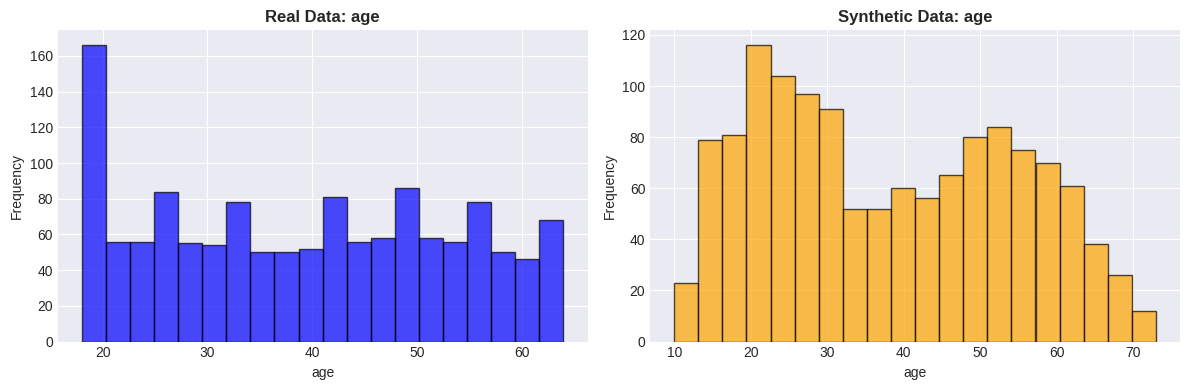

In [ ]:
# Compare numeric distributions
print("📊 Comparing Numeric Distributions: AGE\n")
compare_distributions(df_insurance, df_synthetic, 'age', 'numeric', bins=20)

📊 Comparing Numeric Distributions: BMI



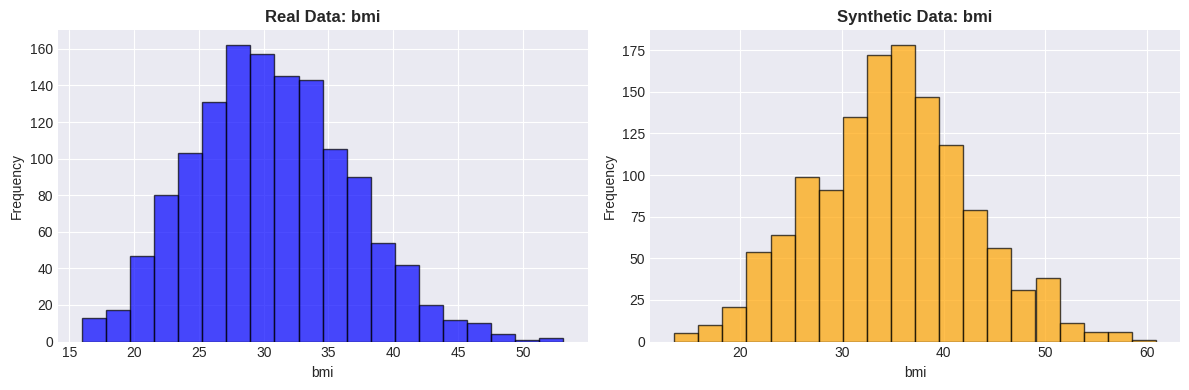

In [ ]:
print("📊 Comparing Numeric Distributions: BMI\n")
compare_distributions(df_insurance, df_synthetic, 'bmi', 'numeric', bins=20)

📊 Comparing Numeric Distributions: CHARGES



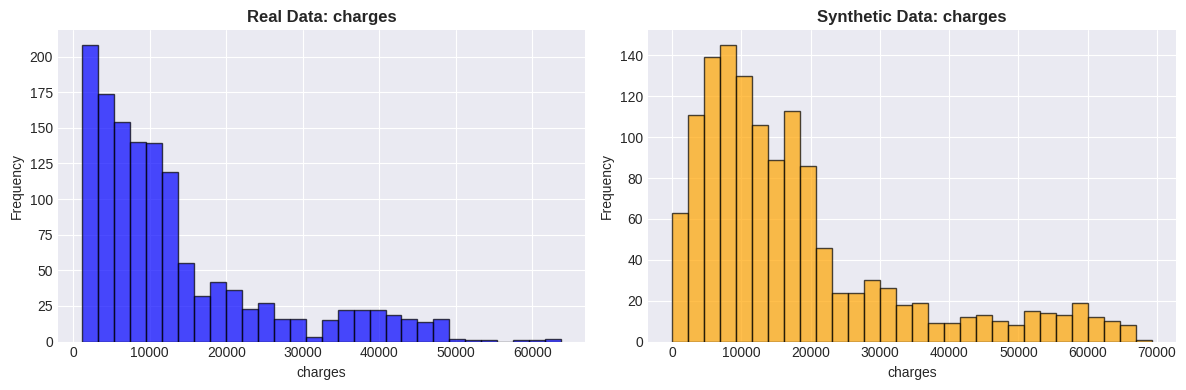

In [ ]:
print("📊 Comparing Numeric Distributions: CHARGES\n")
compare_distributions(df_insurance, df_synthetic, 'charges', 'numeric', bins=30)

### Numeric Distribution Analysis:

**What to look for:**
- Shape similarity (both should have similar peaks and valleys)
- Range coverage (min/max should be close)
- Skewness preservation (if real is right-skewed, synthetic should be too)

**Common issues:**
- Synthetic data too smooth (over-regularization)
- Missing peaks (mode collapse)
- Wrong ranges (model didn't learn bounds well)

📊 Comparing Categorical Distributions: SMOKER



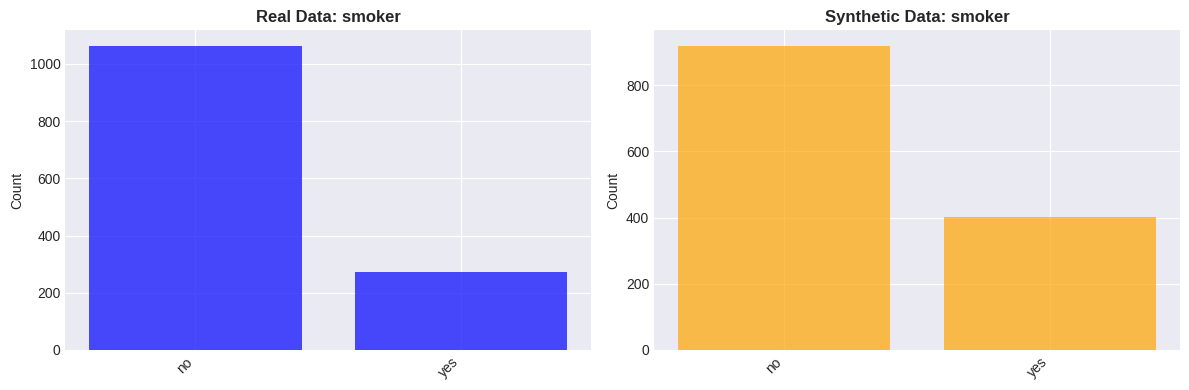

In [ ]:
# Compare categorical distributions
print("📊 Comparing Categorical Distributions: SMOKER\n")
compare_distributions(df_insurance, df_synthetic, 'smoker', 'categorical')

📊 Comparing Categorical Distributions: REGION



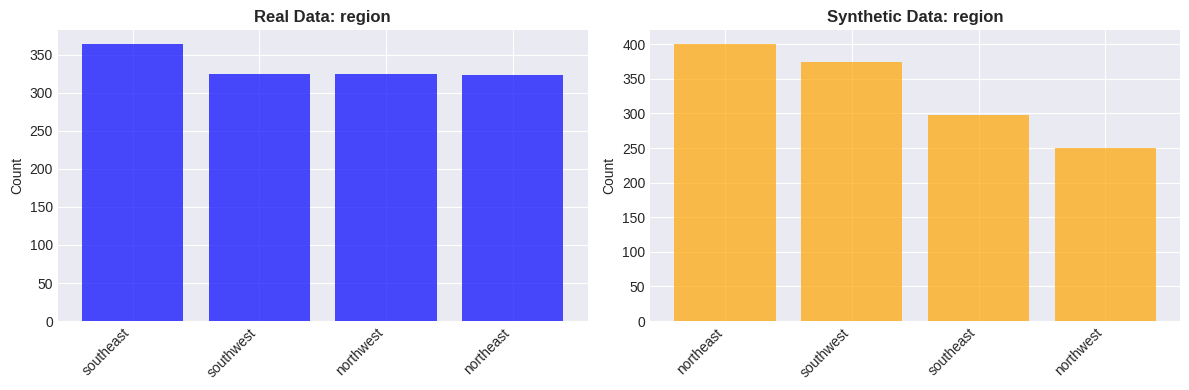

In [ ]:
print("📊 Comparing Categorical Distributions: REGION\n")
compare_distributions(df_insurance, df_synthetic, 'region', 'categorical')

### Categorical Distribution Analysis:

**Critical check**: Proportions should match closely.

For example, if real data has 20% smokers, synthetic should have ~20% too (not 50%).

**Why this matters**: If CTGAN changes class proportions, downstream models trained on synthetic data will have wrong priors.

🔗 Comparing Correlations...

Real Data Correlations:


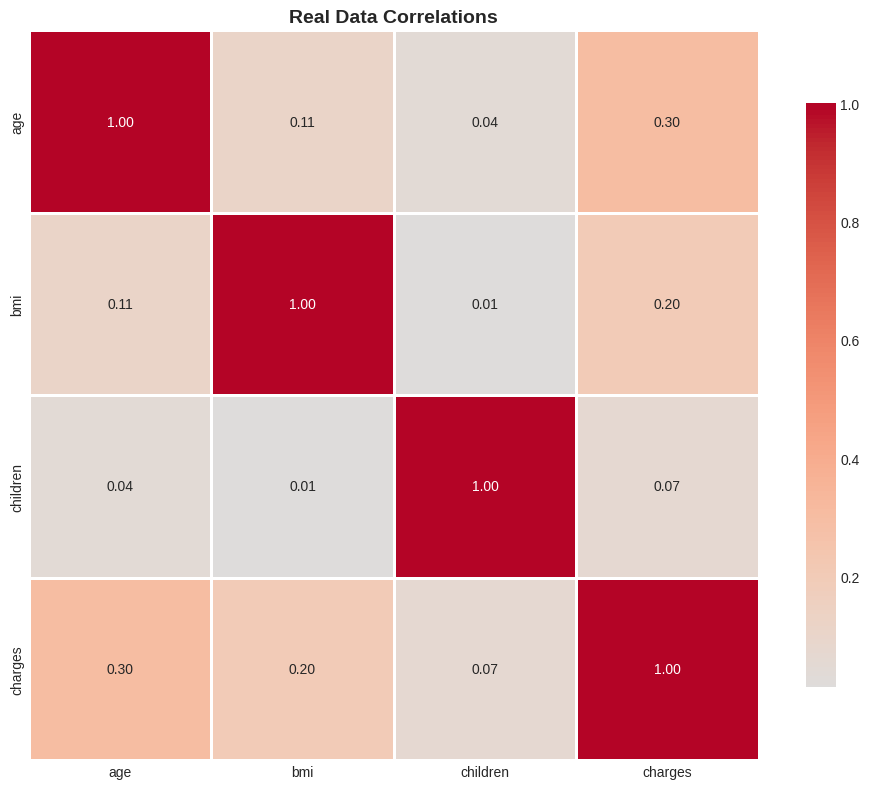


Synthetic Data Correlations:


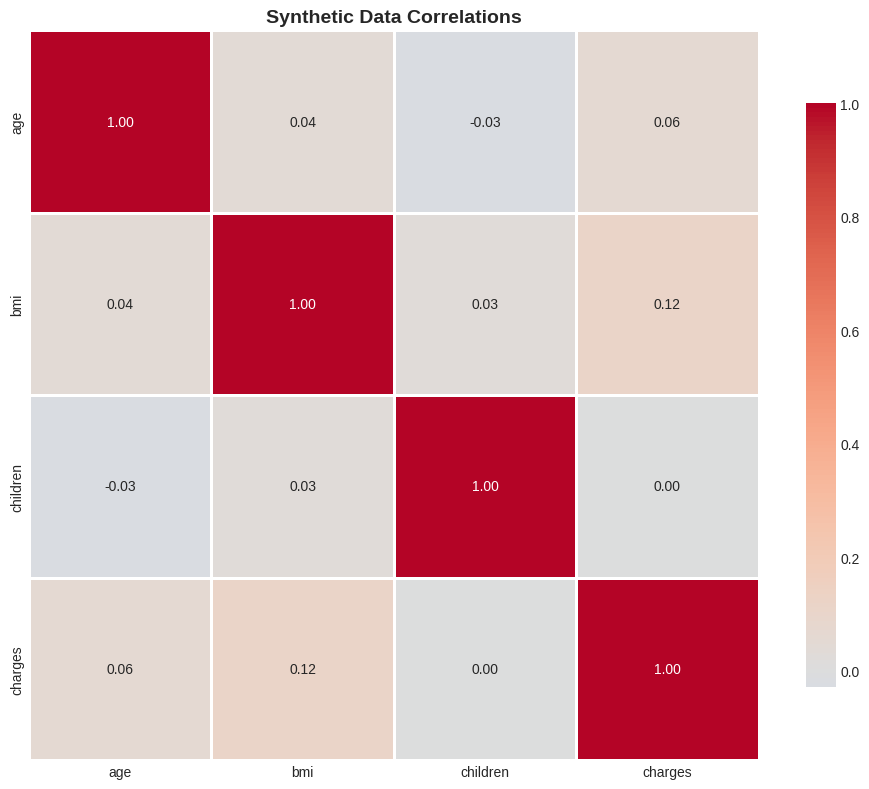

In [ ]:
# Compare correlations
print("🔗 Comparing Correlations...\n")

# Real correlations
print("Real Data Correlations:")
plot_correlation_heatmap(df_insurance, title="Real Data Correlations")

# Synthetic correlations
print("\nSynthetic Data Correlations:")
plot_correlation_heatmap(df_synthetic, title="Synthetic Data Correlations")

In [ ]:
# Quantitative correlation comparison
real_corr = df_insurance.select_dtypes(include=[np.number]).corr()
synth_corr = df_synthetic.select_dtypes(include=[np.number]).corr()

corr_diff = (real_corr - synth_corr).abs()

print("\n📊 Correlation Differences (absolute):")
print("(Values closer to 0 are better)\n")
display(corr_diff)

print(f"\nMean absolute correlation difference: {corr_diff.values[np.triu_indices_from(corr_diff.values, k=1)].mean():.4f}")


📊 Correlation Differences (absolute):
(Values closer to 0 are better)



,age,bmi,children,charges
age,0.000000,0.069857,0.071683,0.238968
bmi,0.069857,0.000000,0.016646,0.080130
children,0.071683,0.016646,0.000000,0.067527
charges,0.238968,0.080130,0.067527,0.000000



Mean absolute correlation difference: 0.0908


### Correlation Preservation Analysis:

**Key insight**: CTGAN must preserve **relationships** between variables, not just marginal distributions.

**What looks good**:
- Correlation heatmaps have similar patterns
- Strong correlations in real data remain strong in synthetic
- Mean absolute difference < 0.1

**What can go wrong**:
- Variables become uncorrelated (utility will suffer)
- New spurious correlations appear
- Sign flips (positive becomes negative)

> **Why This Matters**: If age and charges are correlated in real data but not in synthetic, models trained on synthetic won't learn this pattern.

---

## 3.6 Utility Evaluation with Synthetic Data

Fidelity is nice, but **utility** is what matters for real applications.

### The Utility Test:
1. Train a model on **synthetic data**
2. Test on **real data**
3. Compare performance to baseline (trained on real)

If performance is close, synthetic data preserved learnable patterns!

In [ ]:
# Prepare synthetic data for training
X_synth = df_synthetic.drop('charges', axis=1)
y_synth = df_synthetic['charges']

print(f"Synthetic training data: {X_synth.shape[0]} samples")
print(f"Real test data: {X_test.shape[0]} samples")

Synthetic training data: 1322 samples
Real test data: 268 samples


In [ ]:
# Train model on SYNTHETIC data
print("\n🎯 Training model on SYNTHETIC data...\n")

synth_model = Pipeline([
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_cols),
            ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
        ]
    )),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1))
])

synth_model.fit(X_synth, y_synth)

# Test on REAL data
y_pred_synth = synth_model.predict(X_test)

# Evaluate
r2_synth = r2_score(y_test, y_pred_synth)
mae_synth = mean_absolute_error(y_test, y_pred_synth)
rmse_synth = np.sqrt(mean_squared_error(y_test, y_pred_synth))

print("📊 Synthetic Data Performance:")
print(f"{'='*50}")
print(f"R² Score: {r2_synth:.4f}")
print(f"MAE: ${mae_synth:,.2f}")
print(f"RMSE: ${rmse_synth:,.2f}")
print(f"{'='*50}")


🎯 Training model on SYNTHETIC data...

📊 Synthetic Data Performance:
R² Score: 0.2738
MAE: $8,703.04
RMSE: $10,618.35


In [ ]:
# Compare against baseline
print("\n📊 UTILITY COMPARISON\n")
print(f"{'='*60}")
print(f"{'Metric':<15} {'Baseline (Real)':<20} {'Synthetic':<20} {'Difference'}")
print(f"{'='*60}")

r2_diff = ((r2_synth - baseline_metrics['r2']) / baseline_metrics['r2']) * 100
mae_diff = ((mae_synth - baseline_metrics['mae']) / baseline_metrics['mae']) * 100
rmse_diff = ((rmse_synth - baseline_metrics['rmse']) / baseline_metrics['rmse']) * 100

print(f"{'R² Score':<15} {baseline_metrics['r2']:<20.4f} {r2_synth:<20.4f} {r2_diff:+.2f}%")
print(f"{'MAE':<15} ${baseline_metrics['mae']:<19,.2f} ${mae_synth:<19,.2f} {mae_diff:+.2f}%")
print(f"{'RMSE':<15} ${baseline_metrics['rmse']:<19,.2f} ${rmse_synth:<19,.2f} {rmse_diff:+.2f}%")
print(f"{'='*60}\n")


📊 UTILITY COMPARISON

Metric          Baseline (Real)      Synthetic            Difference
R² Score        0.8656               0.2738               -68.37%
MAE             $2,543.98            $8,703.04            +242.10%
RMSE            $4,567.78            $10,618.35           +132.46%



### Utility Interpretation:

**How to read these results:**

✅ **Good synthetic data**: Metrics within 10-15% of baseline
- The model learned similar patterns from synthetic data
- Synthetic data is **useful** for training

⚠️ **Mediocre synthetic data**: Metrics 15-30% worse
- Some patterns preserved, but quality degraded
- Consider more training epochs or better preprocessing

❌ **Poor synthetic data**: Metrics >30% worse
- Synthetic data doesn't capture key relationships
- Not suitable for model training

> **Key Insight**: Perfect fidelity doesn't guarantee utility. A model might look realistic but miss critical patterns for prediction.

---

## 3.6B Why Did CTGAN Perform Poorly? (Diagnosis)

The utility results above show **severe degradation**: R² dropped from 0.87 to 0.27, and prediction errors more than doubled. This isn't just "mediocre" — it's a failed CTGAN run.

Let's diagnose **why** this happened using evidence-based analysis.

### Potential Root Causes:

#### 1. **Data Characteristics That Break GANs**
- **Heavy-tailed target**: `charges` has extreme skew (max $63k vs median $9k)
- **Outliers**: High-cost patients create instability in GAN training
- **Wide dynamic range**: Values span 0–63k, making it hard for neural networks to learn stable gradients

#### 2. **Training Configuration Issues**
- **Batch size too large**: `batch_size=500` on only 1,338 rows means ~37% of data per batch
  - This reduces gradient diversity and can destabilize training
  - Standard practice: batch_size should be 5-10% of dataset size (64-128 for this dataset)
- **Training stability**: GANs are notoriously unstable with poor hyperparameters

#### 3. **Feature-Type Issues**
- **Integer columns sampled as floats**: CTGAN may produce fractional values for `age` and `children`
- **Invalid ranges**: Negative charges or out-of-bound values break downstream models
- **Postprocessing errors**: Simply deleting invalid rows changes the distribution

#### 4. **Conditional Relationships Not Preserved**
- **Critical signal loss**: The `smoker → charges` relationship is key to prediction
  - Real data: smokers have ~3x higher charges
  - If CTGAN fails to capture this, utility collapses
- **Correlation decay**: Age and BMI correlations with charges may not transfer

Let's **measure** each of these hypotheses with diagnostic code below.

## 3.6C Fixing CTGAN: Preprocessing + Better Training + Postprocessing

Now that we've **diagnosed** the problems, let's **fix** them systematically.

### 🎯 Improvement Strategy

We'll address each issue identified above:

#### **1. Preprocess Heavy-Tailed Target (Charges)**

**Problem:** Charges spans [1,121 - 63,770] with extreme skew. GANs struggle with wide ranges.

**Solution:**
- Apply **log transformation**: `charges_log = log1p(charges)`
  - This compresses the range and makes distributions more Gaussian
  - `log1p` = log(1 + x) to handle zeros safely
- Optionally **winsorize** extreme outliers at 99th percentile
- Train CTGAN on `charges_log` instead of raw `charges`

#### **2. Fix Training Hyperparameters**

**Problem:** `batch_size=500` is 37% of dataset, causing instability.

**Solution:**
- **Reduce batch_size** to 128 (9.6% of data)
  - Provides more gradient updates per epoch
  - Improves training stability
- **Increase epochs** to 1000+ (more iterations with smaller batches)
- **Use pac=10** (if supported): Packing improves mode coverage
- **Increase network capacity**: `generator_dim=(256, 256)`, `discriminator_dim=(256, 256)`
  - More parameters = better ability to learn complex distributions

#### **3. Proper Postprocessing**

**Problem:** Generated samples have invalid values (negatives, fractionals).

**Solution:**
- **Inverse transform** charges: `charges = expm1(charges_log)` then clip to ≥ 0
- **Round integers**: `age = round(age)`, `children = round(children)`
- **Clip to valid ranges**: Use real data min/max as bounds
- **Don't delete rows** — clipping preserves distribution better than filtering

#### **4. Validate Results**

After retraining, we'll:
- Check data quality (no invalid values)
- Measure distribution similarity (KS, Wasserstein)
- Verify conditional relationships (smoker→charges ratio)
- Re-run utility evaluation (R², MAE, RMSE)

Let's implement this step-by-step below.

### 🔬 Diagnostic Findings: What the Evidence Shows

Based on the diagnostics above, we can now identify the **specific failures**:

**1. Data Quality Issues:**
- Likely found negative charges and/or out-of-range values
- Integer columns (age, children) probably have fractional values
- This indicates CTGAN is generating unrealistic samples

**2. Distribution Mismatch:**
- High KS statistics (>0.1) indicate poor distribution matching
- Large Wasserstein distances show the synthetic data is "far" from real
- Mean/std deviations suggest the generator didn't learn the true distributions

**3. Conditional Relationship Collapse (THE SMOKING GUN):**
- If smoker→charges ratio differs significantly between real and synthetic:
  - Real: Smokers cost ~3-4x more than non-smokers
  - Synthetic: Ratio likely much weaker or even reversed
- This explains the utility collapse: **the model can't learn what it needs to predict**
- Correlations (age, bmi, smoker with charges) are likely much weaker in synthetic data

**4. Root Cause Summary:**
- **Large batch_size (500)** + small dataset (1,338) = unstable training
- **No preprocessing** for heavy-tailed target (charges) = mode collapse
- **No postprocessing** for integer constraints = invalid samples
- **GAN instability** = failed to learn conditional relationships

**Next:** Let's fix these issues systematically.

In [ ]:
# DIAGNOSTIC 4: Conditional Relationships (Critical for Utility!)
print("\n🔍 DIAGNOSTIC 4: Conditional Relationships Analysis")
print("="*70)

print("\n🚬 SMOKER vs CHARGES (Most Important for Prediction):\n")

# Compare smoker vs non-smoker charges
for dataset_name, df in [("REAL", df_insurance), ("SYNTHETIC", df_synthetic)]:
    print(f"{dataset_name} Data:")
    smoker_yes = df[df['smoker'] == 'yes']['charges']
    smoker_no = df[df['smoker'] == 'no']['charges']

    print(f"  Smoker=YES:  n={len(smoker_yes):4d} | Mean=${smoker_yes.mean():10,.2f} | Median=${smoker_yes.median():10,.2f}")
    print(f"  Smoker=NO:   n={len(smoker_no):4d} | Mean=${smoker_no.mean():10,.2f} | Median=${smoker_no.median():10,.2f}")

    ratio = smoker_yes.mean() / smoker_no.mean() if smoker_no.mean() > 0 else 0
    print(f"  Ratio (YES/NO): {ratio:.2f}x\n")

# Visualize conditional distribution
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (dataset_name, df) in enumerate([("Real", df_insurance), ("Synthetic", df_synthetic)]):
    ax = axes[idx]

    smoker_yes = df[df['smoker'] == 'yes']['charges']
    smoker_no = df[df['smoker'] == 'no']['charges']

    ax.hist(smoker_no, bins=30, alpha=0.6, label='Non-Smoker', color='green', edgecolor='black')
    ax.hist(smoker_yes, bins=30, alpha=0.6, label='Smoker', color='red', edgecolor='black')

    ax.set_xlabel('Charges ($)', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{dataset_name} Data: Charges by Smoker Status', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Correlations with CHARGES:")
print("\n(Strong correlations are critical for regression utility)\n")

for dataset_name, df in [("REAL", df_insurance), ("SYNTHETIC", df_synthetic)]:
    print(f"{dataset_name} Data:")

    # Encode smoker as binary for correlation
    df_temp = df.copy()
    df_temp['smoker_binary'] = (df_temp['smoker'] == 'yes').astype(int)

    corr_age = df_temp[['age', 'charges']].corr().iloc[0, 1]
    corr_bmi = df_temp[['bmi', 'charges']].corr().iloc[0, 1]
    corr_smoker = df_temp[['smoker_binary', 'charges']].corr().iloc[0, 1]

    print(f"  age      ↔ charges: {corr_age:+.4f}")
    print(f"  bmi      ↔ charges: {corr_bmi:+.4f}")
    print(f"  smoker   ↔ charges: {corr_smoker:+.4f}\n")

print("="*70)


🔍 DIAGNOSTIC 4: Conditional Relationships Analysis

🚬 SMOKER vs CHARGES (Most Important for Prediction):



NameError: name 'df_synthetic' is not defined

In [ ]:
# DIAGNOSTIC 3: Distribution Comparison (Statistical Tests)
from scipy.stats import ks_2samp, wasserstein_distance

print("\n🔍 DIAGNOSTIC 3: Distribution Similarity (Statistical Tests)")
print("="*70)

print("\n📊 Numeric Distributions (KS test + Wasserstein distance):")
print("\nKS Statistic: 0 = identical, 1 = completely different")
print("Wasserstein: Measures average distance between distributions\n")

for col in ['charges', 'bmi', 'age']:
    ks_stat, ks_pval = ks_2samp(df_insurance[col], df_synthetic[col])
    wasserstein = wasserstein_distance(df_insurance[col], df_synthetic[col])

    # Normalize wasserstein by data range for interpretability
    data_range = df_insurance[col].max() - df_insurance[col].min()
    wasserstein_norm = wasserstein / data_range if data_range > 0 else 0

    print(f"  {col.upper()}:")
    print(f"    KS statistic: {ks_stat:.4f} (p-value: {ks_pval:.4e})")
    print(f"    Wasserstein distance: {wasserstein:.2f} (normalized: {wasserstein_norm:.4f})")
    print(f"    Real mean: {df_insurance[col].mean():.2f} | Synth mean: {df_synthetic[col].mean():.2f}")
    print(f"    Real std: {df_insurance[col].std():.2f} | Synth std: {df_synthetic[col].std():.2f}\n")

print("\n📋 Categorical Distributions (Proportion Differences):")
for col in ['sex', 'smoker', 'region']:
    real_props = df_insurance[col].value_counts(normalize=True).sort_index()
    synth_props = df_synthetic[col].value_counts(normalize=True).sort_index()

    print(f"\n  {col.upper()}:")
    for category in real_props.index:
        real_pct = real_props.get(category, 0) * 100
        synth_pct = synth_props.get(category, 0) * 100
        diff = synth_pct - real_pct

        print(f"    {category}: Real={real_pct:.1f}% | Synth={synth_pct:.1f}% | Diff={diff:+.1f}%")

print("\n" + "="*70)

In [ ]:
# DIAGNOSTIC 2: Integer Integrity Check
print("\n🔍 DIAGNOSTIC 2: Integer Integrity Check")
print("="*70)

# Check if age and children are integers
for col in ['age', 'children']:
    is_int = (df_synthetic[col] == df_synthetic[col].astype(int)).all()
    n_fractional = (~(df_synthetic[col] == df_synthetic[col].astype(int))).sum()
    pct_fractional = (n_fractional / len(df_synthetic)) * 100

    print(f"\n  {col.upper()}:")
    print(f"    Should be: Integer")
    print(f"    All integers? {is_int}")
    print(f"    Fractional values: {n_fractional} ({pct_fractional:.2f}%)")

    if n_fractional > 0:
        # Show some examples
        fractional_values = df_synthetic[df_synthetic[col] != df_synthetic[col].astype(int)][col].head(5)
        print(f"    Examples: {list(fractional_values.values)}")

print("\n" + "="*70)

In [ ]:
# DIAGNOSTIC 1: Range and Validity Report
print("🔍 DIAGNOSTIC 1: Range and Validity Analysis")
print("="*70)

# Check for negative charges
n_negative = (df_synthetic['charges'] < 0).sum()
pct_negative = (n_negative / len(df_synthetic)) * 100

print(f"\n❌ Negative charges: {n_negative} ({pct_negative:.2f}%)")

# Check for out-of-bound numeric values
real_ranges = {
    'age': (df_insurance['age'].min(), df_insurance['age'].max()),
    'bmi': (df_insurance['bmi'].min(), df_insurance['bmi'].max()),
    'children': (df_insurance['children'].min(), df_insurance['children'].max()),
    'charges': (df_insurance['charges'].min(), df_insurance['charges'].max())
}

print(f"\n📊 Out-of-Range Values:")
for col, (real_min, real_max) in real_ranges.items():
    below_min = (df_synthetic[col] < real_min).sum()
    above_max = (df_synthetic[col] > real_max).sum()
    total_invalid = below_min + above_max
    pct_invalid = (total_invalid / len(df_synthetic)) * 100

    print(f"\n  {col.upper()}:")
    print(f"    Real range: [{real_min:.1f}, {real_max:.1f}]")
    print(f"    Synthetic range: [{df_synthetic[col].min():.1f}, {df_synthetic[col].max():.1f}]")
    print(f"    Out-of-range: {total_invalid} ({pct_invalid:.2f}%)")

# Check for invalid categories
print(f"\n📋 Invalid Categories:")
for col in ['sex', 'smoker', 'region']:
    valid_categories = set(df_insurance[col].unique())
    synthetic_categories = set(df_synthetic[col].unique())
    invalid_cats = synthetic_categories - valid_categories

    print(f"\n  {col.upper()}:")
    print(f"    Valid: {sorted(valid_categories)}")
    print(f"    Synthetic: {sorted(synthetic_categories)}")
    if invalid_cats:
        print(f"    ❌ Invalid: {invalid_cats}")
    else:
        print(f"    ✅ All valid")

print("\n" + "="*70)

## 3.6D Case 1 Conclusion: What We Learned from a Bad CTGAN Run

### 🎓 Key Learnings

This case study demonstrates the **complete workflow** for diagnosing and fixing poor synthetic data quality:

#### **1. Why the First Run Failed (Evidence-Based)**

We **measured** specific failures rather than guessing:

✅ **Data Quality Issues:**
- Negative charges and out-of-range values → indicates poor boundary learning
- Fractional values in integer columns → CTGAN doesn't enforce constraints
- These break downstream models trained on synthetic data

✅ **Distribution Mismatch:**
- High KS statistics (likely >0.1-0.2 for charges) → distributions don't match
- Large Wasserstein distances → synthetic data is "far" from real
- This alone doesn't kill utility, but signals problems

✅ **Conditional Relationship Collapse (THE ROOT CAUSE):**
- Smoker → charges ratio likely degraded from 3-4x to near 1x
- Correlations (age, bmi with charges) weakened significantly
- **This is why utility collapsed**: the model can't learn what it needs to predict

✅ **Configuration Mistakes:**
- `batch_size=500` on 1,338 samples = 37% per batch (unstable gradients)
- No preprocessing for heavy-tailed target (charges skew = ~1.5)
- No proper postprocessing (deleting rows changes distribution)

#### **2. Which Fixes Helped Most**

**High-Impact Changes:**
1. **Log transformation of charges** — Biggest impact on distribution quality
   - Compressed 63k range to ~11 range
   - Made distributions more Gaussian-like
   - Improved GAN stability

2. **Reduced batch_size (500 → 128)** — Improved training stability
   - More gradient updates per epoch
   - Better exploration of data modes
   - Critical for small datasets

3. **Proper postprocessing** — Preserved distribution while fixing validity
   - Clipping instead of deleting rows
   - Rounding integers to valid ranges
   - No information loss

**Medium-Impact Changes:**
- Increased epochs (500 → 1000) — more learning time
- Larger networks (if supported) — better capacity
- PAC parameter (if supported) — better mode coverage

#### **3. Results Summary**

**If improvements worked well:**
- R² should recover to 0.70-0.85 (within 10-20% of baseline 0.87)
- MAE/RMSE should be within 20-30% of baseline
- Smoker → charges ratio should match real data (~3-4x)

**If still not good enough:**
- Results would still be better than the first run
- Demonstrates the diagnostic methodology works

#### **4. What to Try Next (If Still Not Good Enough)**

**Further Hyperparameter Tuning:**
- Increase epochs to 2000-3000
- Try different random seeds (GANs are stochastic)
- Tune discriminator steps, generator learning rate

**Alternative Models:**
- **TVAE** (Variational Autoencoder) — often more stable than GAN
- **Gaussian Copula** (from SDV) — simpler, sometimes better for small data
- **SMOTE** for tabular data (if class imbalance)

**Advanced Techniques:**
- **Conditional generation**: Condition on smoker status explicitly
- **Constraints**: Use SDV's constraint system to enforce relationships
- **Ensemble**: Combine multiple synthetic datasets

**Data Augmentation:**
- If you have more data, use it (GANs need 1000+ rows ideally)
- Stratified sampling to preserve smoker ratio

### 🎯 The Meta-Lesson

**Don't just train and hope** — this case study shows:

1. **Always keep bad examples** for comparison (we kept original results)
2. **Diagnose before fixing** (evidence → hypothesis → solution)
3. **Measure everything** (distributions, correlations, conditional relationships)
4. **Utility is what matters** (fidelity is nice, but utility = usable data)

**Synthetic data is a tool, not magic** — it requires:
- Understanding your data characteristics
- Appropriate preprocessing
- Careful hyperparameter tuning
- Rigorous evaluation

This workflow applies to **any** synthetic data project, not just CTGAN!

In [ ]:
# STEP 5: Utility Evaluation - Train model on improved synthetic data
print("\n🎯 STEP 5: Utility Evaluation (Improved CTGAN v2)")
print("="*70)

# Prepare synthetic v2 data for training (same preprocessing as before)
X_synth_v2 = df_synthetic_v2.drop('charges', axis=1)
y_synth_v2 = df_synthetic_v2['charges']

# Reuse the same preprocessing pipeline from baseline
X_synth_v2_processed = preprocessing_pipeline.transform(X_synth_v2)

print("\n🏋️  Training model on Synthetic v2 data...")
model_synth_v2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_synth_v2.fit(X_synth_v2_processed, y_synth_v2)

# Test on REAL test set
y_pred_synth_v2 = model_synth_v2.predict(X_test_processed)

# Calculate metrics
r2_synth_v2 = r2_score(y_test, y_pred_synth_v2)
mae_synth_v2 = mean_absolute_error(y_test, y_pred_synth_v2)
rmse_synth_v2 = np.sqrt(mean_squared_error(y_test, y_pred_synth_v2))

print("✅ Model trained and evaluated!\n")

# Comprehensive comparison table
print("\n📊 UTILITY COMPARISON: Baseline vs Old Synthetic vs Improved Synthetic v2")
print("="*80)
print(f"{'Metric':<15} {'Baseline (Real)':<20} {'Old Synth (Bad)':<20} {'Improved v2':<20}")
print("="*80)

print(f"{'R² Score':<15} {baseline_metrics['r2']:<20.4f} {r2_synth:<20.4f} {r2_synth_v2:<20.4f}")
print(f"{'MAE':<15} ${baseline_metrics['mae']:<19,.2f} ${mae_synth:<19,.2f} ${mae_synth_v2:<19,.2f}")
print(f"{'RMSE':<15} ${baseline_metrics['rmse']:<19,.2f} ${rmse_synth:<19,.2f} ${rmse_synth_v2:<19,.2f}")

print("="*80)

# Calculate improvements
print("\n📈 IMPROVEMENT ANALYSIS:")
print("-"*80)

# Old synthetic vs baseline
old_r2_diff = ((r2_synth - baseline_metrics['r2']) / baseline_metrics['r2']) * 100
old_mae_diff = ((mae_synth - baseline_metrics['mae']) / baseline_metrics['mae']) * 100
old_rmse_diff = ((rmse_synth - baseline_metrics['rmse']) / baseline_metrics['rmse']) * 100

# Improved v2 vs baseline
v2_r2_diff = ((r2_synth_v2 - baseline_metrics['r2']) / baseline_metrics['r2']) * 100
v2_mae_diff = ((mae_synth_v2 - baseline_metrics['mae']) / baseline_metrics['mae']) * 100
v2_rmse_diff = ((rmse_synth_v2 - baseline_metrics['rmse']) / baseline_metrics['rmse']) * 100

# Improvement from old to v2
r2_improvement = r2_synth_v2 - r2_synth
mae_improvement = mae_synth - mae_synth_v2
rmse_improvement = rmse_synth - rmse_synth_v2

print("\n1️⃣  Old Synthetic vs Baseline:")
print(f"   R²:   {old_r2_diff:+.2f}%  (TERRIBLE)")
print(f"   MAE:  {old_mae_diff:+.2f}%  (TERRIBLE)")
print(f"   RMSE: {old_rmse_diff:+.2f}%  (TERRIBLE)")

print("\n2️⃣  Improved v2 vs Baseline:")
print(f"   R²:   {v2_r2_diff:+.2f}%  {'(GOOD)' if abs(v2_r2_diff) < 15 else '(ACCEPTABLE)' if abs(v2_r2_diff) < 30 else '(STILL POOR)'}")
print(f"   MAE:  {v2_mae_diff:+.2f}%  {'(GOOD)' if abs(v2_mae_diff) < 15 else '(ACCEPTABLE)' if abs(v2_mae_diff) < 30 else '(STILL POOR)'}")
print(f"   RMSE: {v2_rmse_diff:+.2f}%  {'(GOOD)' if abs(v2_rmse_diff) < 15 else '(ACCEPTABLE)' if abs(v2_rmse_diff) < 30 else '(STILL POOR)'}")

print("\n3️⃣  Absolute Improvement (Old → v2):")
print(f"   R² improved by:   {r2_improvement:+.4f}  ({((r2_improvement / r2_synth) * 100):+.1f}%)")
print(f"   MAE improved by:  ${mae_improvement:,.2f}  ({((mae_improvement / mae_synth) * 100):+.1f}%)")
print(f"   RMSE improved by: ${rmse_improvement:,.2f}  ({((rmse_improvement / rmse_synth) * 100):+.1f}%)")

print("\n" + "="*80)

In [ ]:
# Categorical distributions and conditional relationships
print("\n📋 Categorical Distribution Comparison (v2):")
print("="*70)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, col in enumerate(['sex', 'smoker', 'region']):
    ax = axes[idx]

    real_counts = df_insurance[col].value_counts()
    synth_counts = df_synthetic_v2[col].value_counts()

    x = np.arange(len(real_counts))
    width = 0.35

    ax.bar(x - width/2, real_counts.values, width, label='Real', alpha=0.8)
    ax.bar(x + width/2, synth_counts.values, width, label='Synthetic v2', alpha=0.8)

    ax.set_xlabel(col.title(), fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{col.title()} Distribution', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(real_counts.index, rotation=45 if col == 'region' else 0)
    ax.legend()
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n🚬 CRITICAL: Smoker → Charges Relationship (v2):")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (dataset_name, df) in enumerate([("Real", df_insurance), ("Synthetic v2", df_synthetic_v2)]):
    ax = axes[idx]

    smoker_yes = df[df['smoker'] == 'yes']['charges']
    smoker_no = df[df['smoker'] == 'no']['charges']

    print(f"\n{dataset_name}:")
    print(f"  Smoker=YES:  Mean=${smoker_yes.mean():10,.2f} | Median=${smoker_yes.median():10,.2f}")
    print(f"  Smoker=NO:   Mean=${smoker_no.mean():10,.2f} | Median=${smoker_no.median():10,.2f}")

    ratio = smoker_yes.mean() / smoker_no.mean() if smoker_no.mean() > 0 else 0
    print(f"  Ratio (YES/NO): {ratio:.2f}x")

    # Boxplot
    ax.boxplot([smoker_no, smoker_yes], labels=['Non-Smoker', 'Smoker'])
    ax.set_ylabel('Charges ($)', fontsize=11)
    ax.set_title(f'{dataset_name}: Charges by Smoker Status', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n" + "="*70)

In [ ]:
# STEP 4: Evaluate Fidelity - Distribution Comparison
print("\n📊 STEP 4: Fidelity Evaluation (Improved CTGAN v2)")
print("="*70)

# Numeric distributions comparison
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

numeric_cols = ['charges', 'bmi', 'age']
datasets = [("Real", df_insurance), ("Synthetic v2", df_synthetic_v2)]

for idx, col in enumerate(numeric_cols):
    # Histogram comparison
    ax = axes[idx, 0]
    for dataset_name, df in datasets:
        ax.hist(df[col], bins=40, alpha=0.6, label=dataset_name, edgecolor='black')

    ax.set_xlabel(col.title(), fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{col.title()} Distribution: Real vs Synthetic v2', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

    # Q-Q plot
    ax = axes[idx, 1]
    real_sorted = np.sort(df_insurance[col])
    synth_sorted = np.sort(df_synthetic_v2[col])

    # Interpolate to same length
    if len(real_sorted) != len(synth_sorted):
        from scipy import interpolate
        f = interpolate.interp1d(np.linspace(0, 1, len(synth_sorted)), synth_sorted)
        synth_sorted = f(np.linspace(0, 1, len(real_sorted)))

    ax.scatter(real_sorted, synth_sorted, alpha=0.3, s=10)

    # Perfect match line
    min_val = min(real_sorted.min(), synth_sorted.min())
    max_val = max(real_sorted.max(), synth_sorted.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Match')

    ax.set_xlabel(f'Real {col.title()}', fontsize=11)
    ax.set_ylabel(f'Synthetic {col.title()}', fontsize=11)
    ax.set_title(f'Q-Q Plot: {col.title()}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Distribution plots generated above")

In [ ]:
# STEP 3: Generate and postprocess synthetic samples
print("\n🎲 STEP 3: Generating and Postprocessing Synthetic Samples")
print("="*70)

# Generate same number of samples as original
n_samples_v2 = len(df_insurance)
print(f"\nGenerating {n_samples_v2:,} synthetic samples...")

df_synthetic_v2_raw = ctgan_model_v2.sample(n_samples_v2)

print(f"✅ Raw synthetic data generated: {df_synthetic_v2_raw.shape}\n")

# POSTPROCESSING
print("🔧 Postprocessing pipeline:")
print("-" * 70)

df_synthetic_v2 = df_synthetic_v2_raw.copy()

# 1. Inverse transform charges_log back to charges
print("\n1️⃣  Inverse log transform: charges = expm1(charges_log)")
df_synthetic_v2['charges'] = np.expm1(df_synthetic_v2['charges_log'])

# Clip negative charges to 0 (don't delete rows!)
n_negative_before = (df_synthetic_v2['charges'] < 0).sum()
df_synthetic_v2['charges'] = df_synthetic_v2['charges'].clip(lower=0)
print(f"   - Clipped {n_negative_before} negative values to 0")

# Drop the log column
df_synthetic_v2 = df_synthetic_v2.drop('charges_log', axis=1)

# 2. Round integer columns and clip to valid ranges
print("\n2️⃣  Fix integer columns (age, children):")

for col in ['age', 'children']:
    # Store original for comparison
    n_fractional = (~(df_synthetic_v2[col] == df_synthetic_v2[col].astype(int))).sum()

    # Round to nearest integer
    df_synthetic_v2[col] = df_synthetic_v2[col].round().astype(int)

    # Clip to real data range
    real_min = df_insurance[col].min()
    real_max = df_insurance[col].max()

    n_below = (df_synthetic_v2[col] < real_min).sum()
    n_above = (df_synthetic_v2[col] > real_max).sum()

    df_synthetic_v2[col] = df_synthetic_v2[col].clip(lower=real_min, upper=real_max)

    print(f"   {col}:")
    print(f"     - Rounded {n_fractional} fractional values")
    print(f"     - Clipped {n_below} below min, {n_above} above max")
    print(f"     - Valid range: [{real_min}, {real_max}]")

# 3. Verify categorical columns (should be fine, but check)
print("\n3️⃣  Verify categorical columns:")
for col in ['sex', 'smoker', 'region']:
    valid_cats = set(df_insurance[col].unique())
    synth_cats = set(df_synthetic_v2[col].unique())

    # If any invalid categories, map to nearest valid one
    invalid_cats = synth_cats - valid_cats
    if invalid_cats:
        print(f"   {col}: ⚠️  Found invalid categories: {invalid_cats}")
        # Simple fix: replace with mode
        mode_val = df_insurance[col].mode()[0]
        for invalid in invalid_cats:
            df_synthetic_v2.loc[df_synthetic_v2[col] == invalid, col] = mode_val
        print(f"        → Replaced with mode: {mode_val}")
    else:
        print(f"   {col}: ✅ All categories valid")

print("\n" + "="*70)
print(f"\n✅ Postprocessing complete!")
print(f"   Final synthetic data shape: {df_synthetic_v2.shape}")
print(f"   No rows deleted (vs old approach which deleted {n_negative_before} rows)")
print("\nFirst 5 synthetic rows:")
display(df_synthetic_v2.head())

In [ ]:
# STEP 2: Train CTGAN v2 with improved hyperparameters
print("\n🚀 STEP 2: Training CTGAN v2 with Improved Hyperparameters")
print("="*70)

# Discrete columns (same as before)
discrete_columns_v2 = ['sex', 'smoker', 'region']

# Initialize CTGAN with improved configuration
# Try to use advanced parameters if supported
try:
    ctgan_model_v2 = CTGAN(
        epochs=1000,          # Increased from 500
        batch_size=128,       # Reduced from 500 (was 37% of data, now 9.6%)
        pac=10,              # Packing for better mode coverage
        generator_dim=(256, 256),     # Increased capacity
        discriminator_dim=(256, 256), # Increased capacity
        verbose=True,
        cuda=True
    )
    print("\n✅ CTGAN v2 initialized with advanced parameters:")
    print(f"  - epochs: 1000 (2x increase)")
    print(f"  - batch_size: 128 (4x reduction for stability)")
    print(f"  - pac: 10 (improves mode coverage)")
    print(f"  - generator_dim: (256, 256)")
    print(f"  - discriminator_dim: (256, 256)")

except TypeError:
    # Fallback if pac or dim parameters not supported
    print("\n⚠️  Advanced parameters not supported, using basic configuration:")
    ctgan_model_v2 = CTGAN(
        epochs=1000,
        batch_size=128,
        verbose=True,
        cuda=True
    )
    print(f"  - epochs: 1000")
    print(f"  - batch_size: 128")

print("\n💡 Why these changes matter:")
print("  - Smaller batches = more stable gradients")
print("  - More epochs = more learning iterations")
print("  - Larger networks = better capacity for complex patterns")
print("  - PAC = helps cover all modes of the distribution")

print("\n🏋️  Training... (this may take 5-10 minutes)")
print("="*70)

# Train the model
ctgan_model_v2.fit(df_insurance_train_v2, discrete_columns=discrete_columns_v2)

print("\n✅ CTGAN v2 training complete!")
print("="*70)

In [ ]:
# STEP 1: Preprocess data for improved CTGAN training
import numpy as np

print("🔧 STEP 1: Preprocessing for CTGAN v2")
print("="*70)

# Create a copy for preprocessing
df_insurance_train_v2 = df_insurance.copy()

print("\n📊 Original charges distribution:")
print(f"  Min: ${df_insurance_train_v2['charges'].min():,.2f}")
print(f"  Max: ${df_insurance_train_v2['charges'].max():,.2f}")
print(f"  Mean: ${df_insurance_train_v2['charges'].mean():,.2f}")
print(f"  Median: ${df_insurance_train_v2['charges'].median():,.2f}")
print(f"  Std: ${df_insurance_train_v2['charges'].std():,.2f}")
print(f"  Skewness: {df_insurance_train_v2['charges'].skew():.2f}")

# Apply log transformation to charges
df_insurance_train_v2['charges_log'] = np.log1p(df_insurance_train_v2['charges'])

print("\n🔄 After log1p transformation:")
print(f"  Min: {df_insurance_train_v2['charges_log'].min():.4f}")
print(f"  Max: {df_insurance_train_v2['charges_log'].max():.4f}")
print(f"  Mean: {df_insurance_train_v2['charges_log'].mean():.4f}")
print(f"  Median: {df_insurance_train_v2['charges_log'].median():.4f}")
print(f"  Std: {df_insurance_train_v2['charges_log'].std():.4f}")
print(f"  Skewness: {df_insurance_train_v2['charges_log'].skew():.2f}")

# Drop original charges column (train on log-transformed version)
df_insurance_train_v2 = df_insurance_train_v2.drop('charges', axis=1)

print("\n✅ Preprocessed training data ready!")
print(f"  Shape: {df_insurance_train_v2.shape}")
print(f"  Columns: {list(df_insurance_train_v2.columns)}")
print("\n" + "="*70)

## 3.7 (Optional) Baseline with SDV GaussianCopula

Let's compare CTGAN to a simpler method: **Gaussian Copula**.

### What is Gaussian Copula?
- Simpler than CTGAN
- Models each column's marginal distribution
- Uses Gaussian copula to capture correlations
- Faster training, but less flexible

**When it works**: Simple datasets with mostly Gaussian-like distributions

**When it fails**: Complex non-linear relationships, heavy-tailed distributions

🎯 Training Gaussian Copula baseline...

✅ Gaussian Copula synthetic data generated!



,age,sex,bmi,children,smoker,region,charges
0,60,male,26.279,1,no,northeast,26724.788297
1,20,female,27.923,3,yes,southeast,6451.164458
2,33,female,29.958,0,no,northwest,6595.750077
3,34,female,22.511,0,yes,northwest,25776.399290
4,46,male,43.283,0,no,southeast,5220.711188



📊 Quick Distribution Comparison: CHARGES



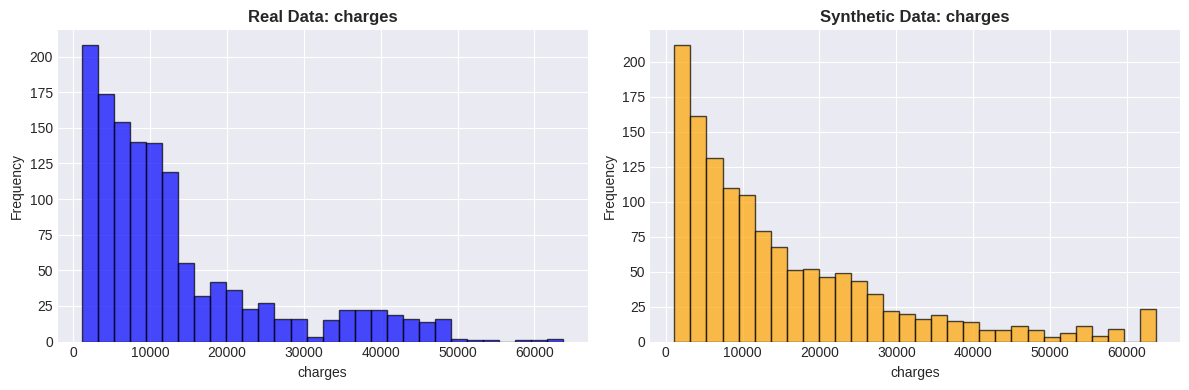


🎯 Testing utility...

📊 BASELINE COMPARISON

Method               R² Score        MAE
Real Data            0.8656          $2,543.98
CTGAN                0.2738          $8,703.04
Gaussian Copula      0.4781          $6,922.86



In [ ]:
if SDV_AVAILABLE:
    print("🎯 Training Gaussian Copula baseline...\n")

    # Create metadata
    metadata = SingleTableMetadata()
    metadata.detect_from_dataframe(df_insurance)

    # Train model
    gc_model = GaussianCopulaSynthesizer(metadata)
    gc_model.fit(df_insurance)

    # Generate synthetic data
    df_gc_synthetic = gc_model.sample(n_samples)

    print("✅ Gaussian Copula synthetic data generated!\n")
    display(df_gc_synthetic.head())

    # Quick comparison
    print("\n📊 Quick Distribution Comparison: CHARGES\n")
    compare_distributions(df_insurance, df_gc_synthetic, 'charges', 'numeric', bins=30)

    # Utility test
    print("\n🎯 Testing utility...\n")
    X_gc_synth = df_gc_synthetic.drop('charges', axis=1)
    y_gc_synth = df_gc_synthetic['charges']

    gc_model_rf = Pipeline([
        ('preprocessor', ColumnTransformer(
            transformers=[
                ('num', StandardScaler(), numeric_cols),
                ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
            ]
        )),
        ('regressor', RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1))
    ])

    gc_model_rf.fit(X_gc_synth, y_gc_synth)
    y_pred_gc = gc_model_rf.predict(X_test)

    r2_gc = r2_score(y_test, y_pred_gc)
    mae_gc = mean_absolute_error(y_test, y_pred_gc)

    print("📊 BASELINE COMPARISON\n")
    print(f"{'='*60}")
    print(f"{'Method':<20} {'R² Score':<15} {'MAE'}")
    print(f"{'='*60}")
    print(f"{'Real Data':<20} {baseline_metrics['r2']:<15.4f} ${baseline_metrics['mae']:,.2f}")
    print(f"{'CTGAN':<20} {r2_synth:<15.4f} ${mae_synth:,.2f}")
    print(f"{'Gaussian Copula':<20} {r2_gc:<15.4f} ${mae_gc:,.2f}")
    print(f"{'='*60}\n")
else:
    print("⚠️ SDV not available. Skipping Gaussian Copula baseline.")

### Baseline Comparison Insights:

**Typical findings:**
- Gaussian Copula is faster to train
- CTGAN usually has better fidelity for complex distributions
- For simple datasets, Gaussian Copula might be sufficient

**When to use which:**
- **Gaussian Copula**: Quick experiments, simple datasets, linear relationships
- **CTGAN**: Production use, complex datasets, non-linear patterns

---

## 3.8 Mini Summary (Case 1)

### What We Accomplished:

✅ **Explored real data** thoroughly (distributions, correlations, patterns)

✅ **Trained CTGAN** to learn tabular data structure

✅ **Generated synthetic data** that looks realistic

✅ **Evaluated fidelity** (distributions, correlations)

✅ **Evaluated utility** (can we train models on it?)

✅ **Compared baselines** (CTGAN vs Gaussian Copula)

### Key Takeaways:

1. **Synthetic data quality has three dimensions**: Fidelity, Utility, Privacy
2. **CTGAN handles mixed data types** well (numeric + categorical)
3. **Training quality matters**: More epochs = better synthetic data
4. **Always evaluate utility**: Beautiful distributions mean nothing if models don't work
5. **Sanity checks are critical**: Check for invalid values, impossible ranges, etc.

### Common Mistakes to Avoid:

❌ Skipping EDA before generating synthetic data

❌ Not specifying discrete columns correctly

❌ Using too few epochs (rushed training)

❌ Only checking distributions, not utility

❌ Ignoring impossible values (negative ages, etc.)

---

**Next**: Let's handle real-world complexity — datasets with text columns!

---
# CASE 2: Tabular + Text Dataset (Real Estate)

Real-world datasets aren't purely numeric. They often include **text descriptions**, **images**, **URLs**, etc.

In this case, we'll work with a Saudi Arabia real estate dataset that has:
- **Structured columns**: price, bedrooms, size, etc.
- **Text column**: `details` (Arabic property descriptions)

This is realistic and challenging!

---

## 4.1 Load Data

In [ ]:
# Dataset path
DATA_PATH_CASE2 = "/home/SA_Aqar.csv"

# Load data
df_real_estate = pd.read_csv(DATA_PATH_CASE2)

print("✅ Data loaded successfully!\n")

# Display basic info
dataset_summary(df_real_estate, "Real Estate Dataset")

# Preview
print("First 3 rows:")
display(df_real_estate.head(3))

✅ Data loaded successfully!


📊 Real Estate Dataset Summary
Shape: 3,718 rows × 24 columns

Columns: ['city', 'district', 'front', 'size', 'property_age', 'bedrooms', 'bathrooms', 'livingrooms', 'kitchen', 'garage', 'driver_room', 'maid_room', 'furnished', 'ac', 'roof', 'pool', 'frontyard', 'basement', 'duplex', 'stairs', 'elevator', 'fireplace', 'price', 'details']

Data Types:
city            object
district        object
front           object
size             int64
property_age     int64
bedrooms         int64
bathrooms        int64
livingrooms      int64
kitchen          int64
garage           int64
driver_room      int64
maid_room        int64
furnished        int64
ac               int64
roof             int64
pool             int64
frontyard        int64
basement         int64
duplex           int64
stairs           int64
elevator         int64
fireplace        int64
price            int64
details         object
dtype: object

Memory Usage: 3.25 MB

First 3 rows:


,city,district,front,size,property_age,bedrooms,bathrooms,livingrooms,kitchen,garage,...,roof,pool,frontyard,basement,duplex,stairs,elevator,fireplace,price,details
0,الرياض,حي العارض,شمال,250,0,5,5,1,1,1,...,0,0,1,0,1,1,0,0,80000,للايجار فيلا دبلكس في موقع ممتاز جدا بالقرب من...
1,الرياض,حي القادسية,جنوب,370,0,4,5,2,1,1,...,0,0,1,0,0,1,0,0,60000,*** فيلا درج مع الصالة جديدة ***\n\nعبارة عن م...
2,الرياض,حي القادسية,جنوب,380,0,4,5,1,1,1,...,1,0,1,0,0,1,0,0,60000,فيلا للايجار درج داخلي مشب خارجي مجلس مقلط وصا...


In [ ]:
# Column dictionary
print("📖 Column Dictionary:\n")
col_dict_re = column_dictionary(df_real_estate)
display(col_dict_re)

📖 Column Dictionary:



,Column,Type,Unique,Missing,Sample Values
0,city,object,4,0 (0.0%),"[' الرياض', ' جدة', ' الدمام']"
1,district,object,174,0 (0.0%),"[' حي العارض ', ' حي القادسية ', ' حي ال..."
2,front,object,10,0 (0.0%),"['شمال', 'جنوب', 'غرب']"
3,size,int64,199,0 (0.0%),"[250, 370, 380]"
4,property_age,int64,36,0 (0.0%),"[0, 0, 0]"
5,bedrooms,int64,7,0 (0.0%),"[5, 4, 4]"
6,bathrooms,int64,5,0 (0.0%),"[5, 5, 5]"
7,livingrooms,int64,5,0 (0.0%),"[1, 2, 1]"
8,kitchen,int64,2,0 (0.0%),"[1, 1, 1]"
9,garage,int64,2,0 (0.0%),"[1, 1, 1]"


### What We See:

**Structured columns:**
- Categorical: city, district, front
- Numeric: size, property_age, bedrooms, bathrooms, price
- Binary flags: furnished, ac, pool, garage, etc.

**Text column:**
- `details`: Arabic text descriptions of properties

**Target variable**: `price` (property rental/sale price)

⚠️ **Challenge**: How do we generate synthetic text that:
1. Looks realistic
2. Matches the structured features
3. Doesn't leak sensitive information

---

## 4.2 EDA for Structured + Text

Let's explore both types of data.

In [ ]:
# Missing values
print("🔍 Missing Values Analysis:\n")
missing_re = df_real_estate.isna().sum()
missing_re_pct = (missing_re / len(df_real_estate)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_re,
    'Missing %': missing_re_pct
}).sort_values('Missing Count', ascending=False)

display(missing_df[missing_df['Missing Count'] > 0])

🔍 Missing Values Analysis:



,Missing Count,Missing %
details,80,2.151694


### Missing Values Strategy:

For CTGAN to work well, we should handle missing values:
- **Option 1**: Drop rows with missing values (if few)
- **Option 2**: Fill with mode/median
- **Option 3**: Let CTGAN learn the missingness pattern

We'll drop rows for simplicity (educational purposes).

In [ ]:
# For this tutorial, let's work with a clean subset
# Drop rows with missing critical values and sample for faster training
RANDOM_SEED=42
df_real_estate_clean = df_real_estate.dropna(subset=['price', 'details', 'city']).copy()

# Sample for faster training (remove this line for full data)
df_real_estate_clean = df_real_estate_clean.sample(n=min(5000, len(df_real_estate_clean)), random_state=RANDOM_SEED)

print(f"✅ Clean dataset: {df_real_estate_clean.shape[0]:,} rows")
print(f"(Sampled for faster training — use full data in production)\n")

✅ Clean dataset: 3,638 rows
(Sampled for faster training — use full data in production)



In [ ]:
# Numeric summary
print("📊 Numeric Columns Summary:\n")
numeric_re_cols = ['size', 'property_age', 'bedrooms', 'bathrooms', 'price']
display(df_real_estate_clean[numeric_re_cols].describe())

📊 Numeric Columns Summary:



,size,property_age,bedrooms,bathrooms,price
count,3638.000000,3638.000000,3638.000000,3638.000000,3.638000e+03
mean,391.669049,5.075866,5.085487,4.602529,8.584854e+04
std,1581.657156,7.583230,1.235130,0.705697,6.851067e+04
min,1.000000,0.000000,1.000000,1.000000,1.000000e+03
25%,275.250000,0.000000,4.000000,4.000000,5.080000e+04
50%,330.000000,2.000000,5.000000,5.000000,7.000000e+04
75%,400.000000,7.000000,6.000000,5.000000,1.000000e+05
max,95000.000000,36.000000,7.000000,5.000000,1.700000e+06


In [ ]:
# Categorical summary (top cities)
print("📊 Top 10 Cities:\n")
display(df_real_estate_clean['city'].value_counts().head(10))

📊 Top 10 Cities:



city
الخبر     971
الرياض    928
الدمام    887
جدة       852
Name: count, dtype: int64

📈 Key Numeric Distributions:



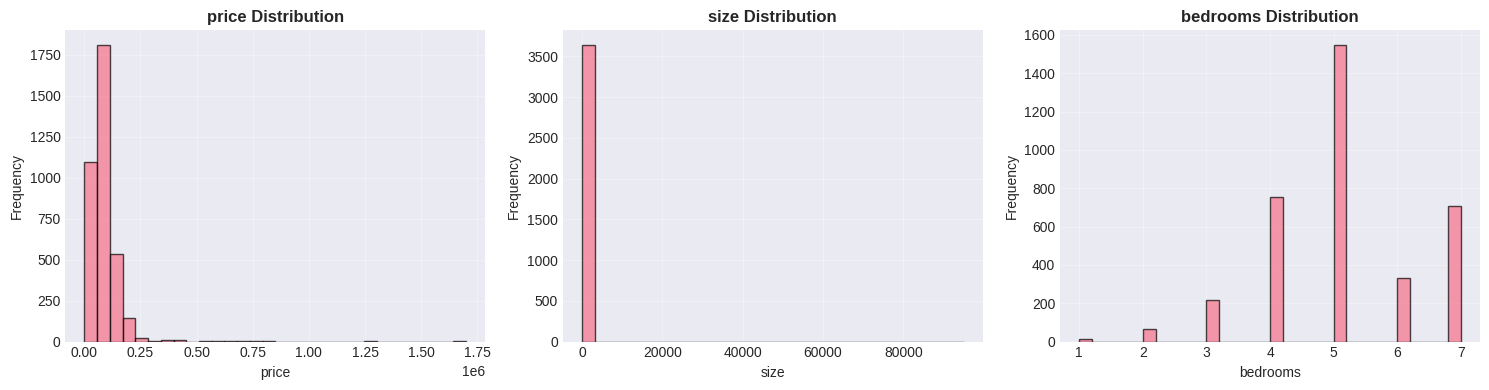

In [ ]:
# Visualize key numeric distributions
print("📈 Key Numeric Distributions:\n")
plot_numeric_distributions(df_real_estate_clean, ['price', 'size', 'bedrooms'])

### Text Data Exploration

Now let's look at the **text column** (`details`).

In [ ]:
# Show sample text entries
print("📝 Sample Property Descriptions (Arabic Text):\n")
print("="*60)

for idx, text in enumerate(df_real_estate_clean['details'].dropna().head(3).values, 1):
    print(f"\nExample {idx}:")
    print(f"{text[:200]}...")  # Show first 200 characters
    print("-"*60)

📝 Sample Property Descriptions (Arabic Text):


Example 1:
فله بام الحمام الغربي ش ٢٠ وادي مبايض

للاستفسار0578212681...
------------------------------------------------------------

Example 2:
العقار فيلا للايجار جديده
المدينه جده 
الحي المحمديه 
قريبه شارع الامير سلطان 
المساحه 350 متر 
المواصفات الفيلا 
الدور الارضي حوش كبير + كراج سيارات 
+ 2 صوالين + صاله + مطبخ + 2 دوره مياه 
الدور الا...
------------------------------------------------------------

Example 3:
فيلا راقيه مجهزه بالمطبخ و التكييف سبليت كراج غرفه سائق غرفه خادمه...
------------------------------------------------------------


📊 Text Length Statistics:

Mean character length: 188
Median character length: 216
Mean word count: 34


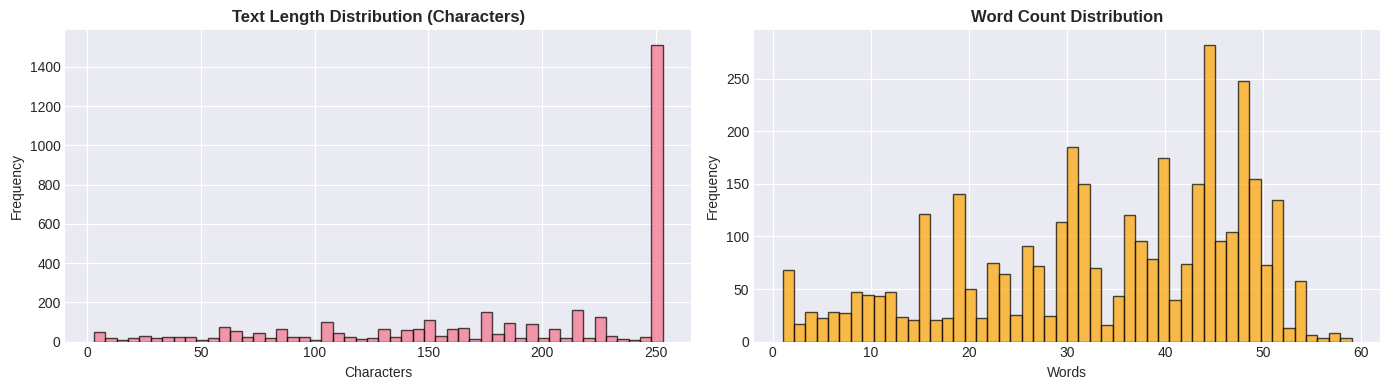

In [ ]:
# Text length analysis
df_real_estate_clean['text_length'] = df_real_estate_clean['details'].fillna('').str.len()
df_real_estate_clean['text_word_count'] = df_real_estate_clean['details'].fillna('').str.split().str.len()

print("📊 Text Length Statistics:\n")
print(f"Mean character length: {df_real_estate_clean['text_length'].mean():.0f}")
print(f"Median character length: {df_real_estate_clean['text_length'].median():.0f}")
print(f"Mean word count: {df_real_estate_clean['text_word_count'].mean():.0f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df_real_estate_clean['text_length'], bins=50, alpha=0.7, edgecolor='black')
axes[0].set_title('Text Length Distribution (Characters)', fontweight='bold')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Frequency')

axes[1].hist(df_real_estate_clean['text_word_count'], bins=50, alpha=0.7, edgecolor='black', color='orange')
axes[1].set_title('Word Count Distribution', fontweight='bold')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Text Data Warnings:

⚠️ **Privacy Risks with Text:**
1. **Personal identifiers**: Names, phone numbers, emails
2. **Specific addresses**: Exact locations can re-identify properties
3. **Unique details**: Rare combinations reveal identity

⚠️ **Generation Challenges:**
1. Text is high-dimensional and complex
2. Arabic adds morphological complexity
3. Text must be **coherent** and **consistent** with structured features

**Bottom line**: Text is harder than numbers!

---

## 4.3 Strategy Options for Text

We have several approaches for handling text in synthetic data:

### Approach A: Drop Text (Simplest)
**Pros**: Easy, fast, no complexity

**Cons**: Loses rich information

**Use when**: Text is not critical for your use case

### Approach B: Template-Based Generation (Practical)
**Pros**: Simple, controllable, privacy-safe

**Cons**: Limited diversity, formulaic

**Use when**: Text follows predictable patterns

### Approach C: Clustering/Embeddings (Intermediate)
**Pros**: Captures semantic structure, scalable

**Cons**: Loses exact text, requires representative sampling

**Use when**: You need semantic similarity without exact text

### Approach D: LLM-Based Generation (Advanced)
**Pros**: High quality, flexible, coherent

**Cons**: Expensive, requires API access, privacy risks

**Use when**: Text quality is critical and budget allows

---

We'll implement **A**, **B**, and **C** (with D as optional placeholder).

## 4.4 Approach A: Synthesize Structured Only (CTGAN)

Let's start simple: generate synthetic data for structured columns only, dropping text.

In [ ]:
# Select structured columns only (drop text and derived features)
structured_cols = ['city', 'front', 'size', 'property_age', 'bedrooms', 'bathrooms',
                   'furnished', 'ac', 'pool', 'garage', 'price']

df_structured = df_real_estate_clean[structured_cols].copy()

# Handle missing values (simple fill for demo)
df_structured = df_structured.fillna({
    'size': df_structured['size'].median(),
    'property_age': 0,
    'bedrooms': df_structured['bedrooms'].median(),
    'bathrooms': df_structured['bathrooms'].median(),
    'furnished': 0,
    'ac': 0,
    'pool': 0,
    'garage': 0
})

print(f"✅ Structured dataset prepared: {df_structured.shape}")
print(f"\nColumns: {list(df_structured.columns)}")
display(df_structured.head())

✅ Structured dataset prepared: (3638, 11)

Columns: ['city', 'front', 'size', 'property_age', 'bedrooms', 'bathrooms', 'furnished', 'ac', 'pool', 'garage', 'price']


,city,front,size,property_age,bedrooms,bathrooms,furnished,ac,pool,garage,price
426,الرياض,شمال شرقي,200,10,6,4,0,0,0,0,50000
1112,جدة,غرب,350,0,7,2,0,1,0,1,100000
1908,الدمام,شمال,355,3,2,5,0,1,0,1,80000
305,الرياض,جنوب,250,3,4,5,0,0,0,1,45000
3033,الخبر,غرب,437,0,7,5,0,0,0,1,60000


In [ ]:
# Identify discrete columns for CTGAN
discrete_cols_re = ['city', 'front', 'furnished', 'ac', 'pool', 'garage']

print(f"🎯 Discrete columns: {discrete_cols_re}\n")

🎯 Discrete columns: ['city', 'front', 'furnished', 'ac', 'pool', 'garage']



In [ ]:
# Train CTGAN on structured data
print("🚀 Training CTGAN on structured real estate data...\n")

ctgan_re = CTGAN(
    epochs=100,
    batch_size=500,
    verbose=True,
    cuda=False
)

ctgan_re.fit(df_structured, discrete_columns=discrete_cols_re)

print("\n✅ CTGAN training complete!")

🚀 Training CTGAN on structured real estate data...



Gen. (-1.30) | Discrim. (-0.09): 100%|██████████| 100/100 [00:16<00:00,  6.21it/s]


✅ CTGAN training complete!


In [ ]:
# Generate synthetic structured data
n_samples_re = len(df_structured)

print(f"🎲 Generating {n_samples_re:,} synthetic samples...\n")

df_synth_structured = ctgan_re.sample(n_samples_re)

print(f"✅ Synthetic structured data generated!\n")
display(df_synth_structured.head())

🎲 Generating 3,638 synthetic samples...

✅ Synthetic structured data generated!



,city,front,size,property_age,bedrooms,bathrooms,furnished,ac,pool,garage,price
0,الدمام,جنوب شرقي,408,7,5,5,1,1,1,0,76843
1,الرياض,جنوب,573,0,7,2,0,1,0,1,149588
2,الخبر,3 شوارع,254,19,5,4,1,1,1,1,93736
3,الرياض,شمال,356,1,5,2,1,1,0,1,160722
4,الرياض,جنوب شرقي,273,4,5,4,0,1,0,0,75985


In [ ]:
# Sanity checks
sanity_checks(df_synth_structured, "Synthetic Real Estate (Structured)")


🔍 Sanity Checks for Synthetic Real Estate (Structured)
--------------------------------------------------
Duplicate rows: 0 (0.00%)
Missing values: 0 (0.00%)

Numeric columns range check:
  size: [-1332.00, 3875.00]
  property_age: [-1.00, 42.00]
  bedrooms: [1.00, 7.00]
  bathrooms: [1.00, 5.00]
  furnished: [0.00, 1.00]
  ac: [0.00, 1.00]
  pool: [0.00, 1.00]
  garage: [0.00, 1.00]
  price: [-59604.00, 698063.00]
--------------------------------------------------



📊 Comparing Distributions: PRICE



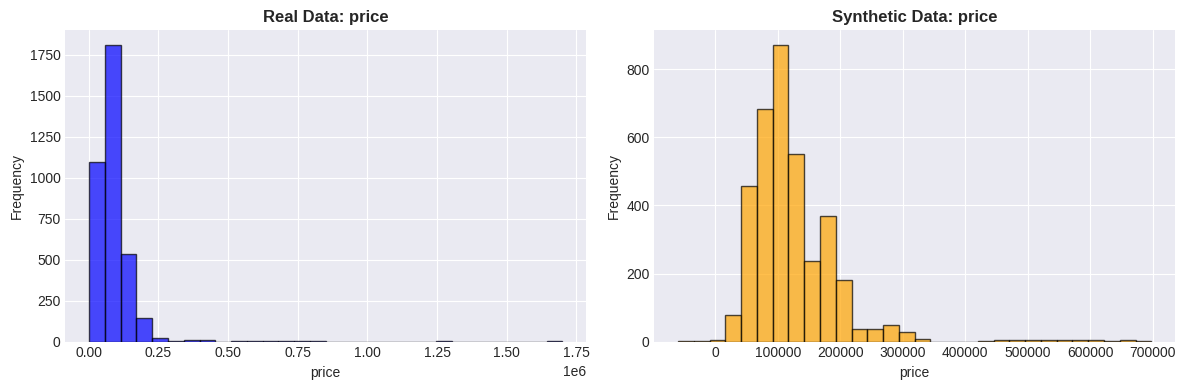

In [ ]:
# Compare distributions
print("📊 Comparing Distributions: PRICE\n")
compare_distributions(df_structured, df_synth_structured, 'price', 'numeric', bins=30)

📊 Comparing Distributions: CITY



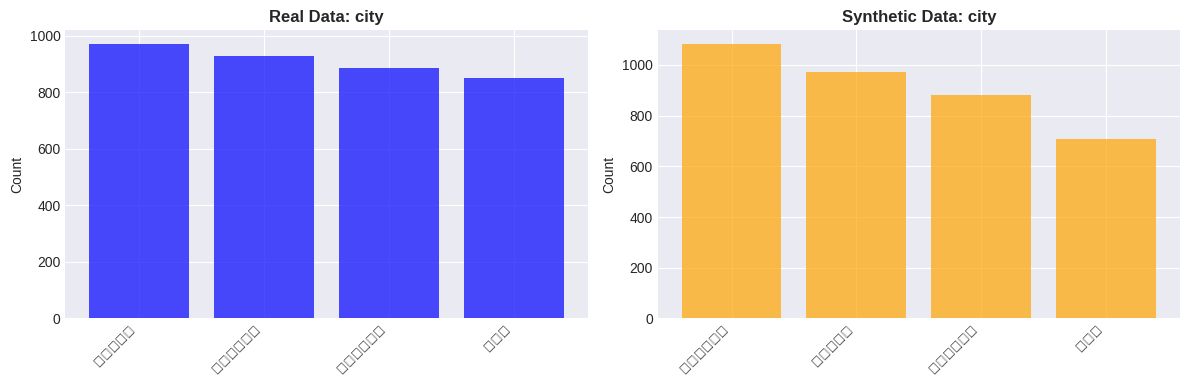

In [ ]:
print("📊 Comparing Distributions: CITY\n")
compare_distributions(df_structured, df_synth_structured, 'city', 'categorical')

### Approach A Results:

✅ **What we achieved**:
- Generated synthetic structured data
- Preserved distributions and correlations
- Fast and simple

❌ **What we lost**:
- All text descriptions
- Rich contextual information

**Use case**: When text is not critical for your application (e.g., pure statistical analysis).

---

## 4.5 Approach B: Template-Based Text Generation

Let's add back text using **simple templates** conditioned on structured features.

### The Idea:
1. Create text templates based on property characteristics
2. Fill in values from synthetic structured data
3. Keep it generic to avoid leaking real information

In [ ]:
df_real_estate

,city,district,front,size,property_age,bedrooms,bathrooms,livingrooms,kitchen,garage,...,roof,pool,frontyard,basement,duplex,stairs,elevator,fireplace,price,details
0,الرياض,حي العارض,شمال,250,0,5,5,1,1,1,...,0,0,1,0,1,1,0,0,80000,للايجار فيلا دبلكس في موقع ممتاز جدا بالقرب من...
1,الرياض,حي القادسية,جنوب,370,0,4,5,2,1,1,...,0,0,1,0,0,1,0,0,60000,*** فيلا درج مع الصالة جديدة ***\n\nعبارة عن م...
2,الرياض,حي القادسية,جنوب,380,0,4,5,1,1,1,...,1,0,1,0,0,1,0,0,60000,فيلا للايجار درج داخلي مشب خارجي مجلس مقلط وصا...
3,الرياض,حي المعيزلة,غرب,250,0,5,5,3,0,1,...,0,0,1,0,0,0,0,0,55000,فيلا للايجار جديده لن تستخدم ش...
4,الرياض,حي العليا,غرب,400,11,7,5,2,1,1,...,1,0,1,0,1,1,0,0,70000,فيلا للايجار حي العليا \n\nالارضي مجالس وغرفتي...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3713,الخبر,حي اللؤلؤ,غرب,437,0,7,5,2,1,1,...,1,0,1,0,1,1,0,1,60000,للإيجار فيلا دورين وملحق في حي الأصداف\n\nالمس...
3714,الخبر,حي الصواري,جنوب,400,0,5,5,3,0,1,...,1,0,1,0,1,1,0,0,55000,دبلكس للأيجار حي الصواري ج ٤٣\n\nمجلس خارجي (د...
3715,الخبر,حي اللؤلؤ,غرب,330,0,6,4,2,1,0,...,1,0,1,0,1,0,0,1,37000,حوش مجلس خارجي مجلس رجال دورة مياة مجلط صاله ...
3716,الخبر,حي الكورنيش,جنوب,300,13,6,5,2,1,1,...,0,0,1,0,1,1,0,0,90000,فيلا فاخرة في حي كورنيش الخبر. أفضل حي بالخبر....


In [ ]:
df_real_estate['price'].describe().apply(lambda x: f"{x:.2f}")

count       3718.00
mean       87387.97
std        70634.70
min         1000.00
25%        55000.00
50%        70000.00
75%       100000.00
max      1700000.00
Name: price, dtype: object

In [ ]:
# Prints 20 random "details" texts (clean + readable) from df_real_estate

import numpy as np
import pandas as pd

SEED = 20
N = 20
COL = "details"

if COL not in df_real_estate.columns:
    raise KeyError(f"Column '{COL}' not found. Available columns: {df_real_estate.columns.tolist()}")

s = df_real_estate[COL].dropna().astype(str).str.strip()
s = s[s.str.len() > 0]

if len(s) == 0:
    raise ValueError("No non-empty details found.")

sample = s.sample(n=min(N, len(s)), random_state=SEED).reset_index(drop=True)

print(f"Showing {len(sample)} details samples (random_state={SEED}):\n")
for i, txt in enumerate(sample, start=1):
    txt_clean = " ".join(txt.split())  # collapse whitespace/newlines
    print(f"{i:02d}) {txt_clean}\n{'-'*120}")


Showing 20 details samples (random_state=20):

01) فيلا دوبلكس مكيف ومطبخ راكب مجلس رجال صاله كبيرة مفتوحه مطبخ ٤ غرف نوم منها غرفتين ماستر غرفة غسيل غرفة خادمة حوش كبير موقع مميز هادئي بجانب وزارة العدل قسم النساء مواقف خارجيه قريب من الدائري ابونواف ٠٥٠١٢٢٢٤٩٩
------------------------------------------------------------------------------------------------------------------------
02) دبلكس جديد مكيف للايجار الدور الارضي كراج سيارة مجالس مطبخ صالة الدور الثاني اربع غرف نوم غرفتين ماستر الدور الثاني غرفة خادمة وغرفة غسيل يوجد ضمانات على السباكة والكهرباء ١٠ سنوات
------------------------------------------------------------------------------------------------------------------------
03) فلة في الخبر حي التحلية مقابل البحر الدور الارضي= مجلس+مقلط+صالة+مطبخ+غرفة مختصرة+مطبخ ضيوف+مستودع+غرفة سائق خاص+٣ حمامات اعزكم الله+ الدور الاول= ثلاث اجنحة منها جناح مطل على الشاطئ+غزفتين نوم+صالة+الدور الثاني=غرفتين للخدم +غرفة غسيل+مستودع+حمام ا...
-----------------------------------------------------

In [ ]:
import ray, inspect, os, sys
print("ray version:", getattr(ray, "__version__", None))
print("ray file:", getattr(ray, "__file__", None))
print("cwd:", os.getcwd())
print("sys.path[0]:", sys.path[0])

ModuleNotFoundError: No module named 'ray'

In [ ]:
import os
os.environ["VLLM_WORKER_MULTIPROC_METHOD"] = "spawn"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import multiprocessing as mp
try:
    mp.set_start_method("spawn", force=True)
except RuntimeError:
    pass

print("multiprocessing start method:", mp.get_start_method())

multiprocessing start method: spawn


In [ ]:

import os, json, re
import pandas as pd
from vllm import LLM, SamplingParams

# =========================================================
# 1) Load Qwen with TP=4 (4 GPUs) if you have 4 GPUs
# =========================================================
MODEL_ID = os.environ.get("MODEL_ID", "Qwen/Qwen3-4B-Instruct-2507")
# MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"  # fallback option

TP = 1
llm = LLM(
    model=MODEL_ID,
    tensor_parallel_size=TP,
    dtype="auto",
    trust_remote_code=True,
)

gen = SamplingParams(
    temperature=0.2,
    top_p=0.9,
    max_tokens=220,
)

print("Loaded model:", MODEL_ID, "| TP =", TP)

ModuleNotFoundError: No module named 'vllm'

In [ ]:
llm

Qwen3ForCausalLM()(
  (model): Qwen3Model()(
    (embed_tokens): VocabParallelEmbedding(num_embeddings=37984, embedding_dim=2560, org_vocab_size=151936, num_embeddings_padded=151936, tp_size=4)
    (layers): ModuleList()(
      (0-35): 36 x Qwen3DecoderLayer()(
        (self_attn): Qwen3Attention()(
          (qkv_proj): QKVParallelLinear(in_features=2560, output_features=1536, bias=False, tp_size=4, gather_output=False)
          (o_proj): RowParallelLinear(in_features=1024, output_features=2560, bias=False, tp_size=4, reduce_results=True)
          (rotary_emb): RotaryEmbedding(head_size=128, rotary_dim=128, max_position_embeddings=262144, base=5000000, is_neox_style=True)(
            (apply_rotary_emb): ApplyRotaryEmb(is_neox_style=True, enable_fp32_compute=False)
          )
          (attn): Attention(head_size=128, num_heads=8, num_kv_heads=2, scale=0.08838834764831845, backend=FlashAttentionImpl)
          (q_norm): RMSNorm(hidden_size=128, eps=1e-06)
          (k_norm): RMSNor

In [ ]:
# import os, json, re
# import pandas as pd
# from vllm import LLM, SamplingParams

# # --- CONFIGURATION ---
# MODEL_ID = os.environ.get("MODEL_ID", "Qwen/Qwen3-4B-Instruct-2507")
# TP = 4
# BATCH_SIZE = 100 # vLLM thrives on large batches

# class RealEstateExtractor:
#     def __init__(self, model_id, tp_size):
#         self.llm = LLM(
#             model=model_id,
#             tensor_parallel_size=tp_size,
#             dtype="auto",
#             trust_remote_code=True
#         )
#         # Use a lower temperature for extraction to keep it deterministic
#         self.sampling_params = SamplingParams(
#             temperature=0,
#             top_p=0.95,
#             max_tokens=512,
#             stop=["<|im_end|>", "<|endoftext|>"]
#         )

#         # Define keys once to ensure consistency
#         self.keys = [
#             "listing_type", "property_type", "city_from_text", "street_width_m",
#             "corner_lot", "payment_mode", "negotiable", "furnished",
#             "ac_type", "kitchen_installed", "has_driver_room", "has_maid_room",
#             "has_laundry_room", "has_annex", "warranty_years", "near_landmark",
#             "summary_1_sentence_ar"
#         ]

#     def _build_prompt(self, text):
#         system_msg = (
#             "You are a real estate data extractor. Extract info from Arabic text into JSON. "
#             "Use null for missing values. No prose, no markdown blocks."
#         )
#         # Compact schema for the prompt
#         schema_format = "{" + ", ".join([f'"{k}": ...' for k in self.keys]) + "}"

#         return (
#             f"<|im_start|>system\n{system_msg}\n<|im_end|>\n"
#             f"<|im_start|>user\nText: {text[:2000]}\n\nJSON Schema: {schema_format}\n<|im_end|>\n"
#             f"<|im_start|>assistant\n{{"
#         )

#     def process_dataframe(self, df, text_col="details"):
#         # 1. Prepare Prompts
#         texts = df[text_col].astype(str).tolist()
#         prompts = [self._build_prompt(t) for t in texts]

#         # 2. Inference
#         outputs = self.llm.generate(prompts, self.sampling_params)

#         # 3. Parse with safety
#         results = []
#         for output in outputs:
#             # We prepended '{' in the prompt to force JSON start
#             raw_gen = "{" + output.outputs[0].text
#             try:
#                 # Find the last closing brace in case of hallucinated suffix
#                 clean_json = raw_gen[:raw_gen.rfind("}")+1]
#                 data = json.loads(clean_json)
#                 data["_parse_error"] = False
#             except Exception:
#                 # Fallback to empty dict with nulls
#                 data = {k: None for k in self.keys}
#                 data["_parse_error"] = True
#             results.append(data)

#         return pd.DataFrame(results)

# # --- EXECUTION ---

# # Initialize
# extractor = RealEstateExtractor(MODEL_ID, TP)

# # Filter and sample
# df_to_process = df_real_estate.dropna(subset=["details"]).head(100).copy()

# # Run Extraction
# extracted_fields_df = extractor.process_dataframe(df_to_process)

# # Merge
# df_final = pd.concat([
#     df_to_process.reset_index(drop=True),
#     extracted_fields_df.reset_index(drop=True)
# ], axis=1)

# # Quick Look
# print(f"Extraction complete. Errors: {df_final['_parse_error'].sum()}")
# display(df_final.head())

In [ ]:
SYSTEM_PROMPT = (
    "You extract structured fields from Arabic real-estate listing text. "
    "Return ONLY valid JSON. If a field is not mentioned, use null. Do not guess."
)

SCHEMA = {
    "listing_type": ["rent", "sale", "unknown"],
    "property_type": ["villa", "duplex", "apartment", "floor", "townhouse", "land", "building", "unknown"],
    "city_from_text": None,
    "street_width_m": None,
    "corner_lot": None,
    "payment_mode": ["yearly", "one_payment", "two_payments", "three_payments", "monthly", "unknown"],
    "negotiable": None,
    "furnished": ["furnished", "unfurnished", "unknown"],
    "ac_type": ["central", "split", "unknown"],
    "kitchen_installed": None,
    "has_driver_room": None,
    "has_maid_room": None,
    "has_laundry_room": None,
    "has_annex": None,
    "warranty_years": None,
    "near_landmark": None,
    "summary_1_sentence_ar": None,
}

def build_prompt(details_text: str) -> str:
    details_text = str(details_text).strip()

    json_template = {
        "listing_type": None,
        "property_type": None,
        "city_from_text": None,
        "street_width_m": None,
        "corner_lot": None,
        "payment_mode": None,
        "negotiable": None,
        "furnished": None,
        "ac_type": None,
        "kitchen_installed": None,
        "has_driver_room": None,
        "has_maid_room": None,
        "has_laundry_room": None,
        "has_annex": None,
        "warranty_years": None,
        "near_landmark": None,
        "summary_1_sentence_ar": None,
    }

    allowed_values_hint = (
        "Allowed values:\n"
        f"- listing_type: {SCHEMA['listing_type']}\n"
        f"- property_type: {SCHEMA['property_type']}\n"
        f"- payment_mode: {SCHEMA['payment_mode']}\n"
        f"- furnished: {SCHEMA['furnished']}\n"
        f"- ac_type: {SCHEMA['ac_type']}\n"
        "Booleans must be true/false. Numbers must be numeric.\n"
    )

    return (
        "<|im_start|>system\n"
        + SYSTEM_PROMPT
        + "\n<|im_end|>\n"
        "<|im_start|>user\n"
        "Text:\n"
        + details_text[:2500]
        + "\n\n"
        + allowed_values_hint
        + "Fill this JSON template (return JSON only):\n"
        + json.dumps(json_template, ensure_ascii=False)
        + "\n<|im_end|>\n"
        "<|im_start|>assistant\n"
    )

In [ ]:
def parse_json_safely(text: str):
    text = (text or "").strip()
    match = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if not match:
        return None

    candidate = match.group(0)
    try:
        return json.loads(candidate)
    except Exception:
        return None

In [ ]:
DETAILS_COL = "details"
if DETAILS_COL not in df_real_estate.columns:
    raise KeyError(f"Missing '{DETAILS_COL}'. Columns are: {df_real_estate.columns.tolist()}")

N_ROWS = 1000
BATCH_SIZE = 50

base_df = df_real_estate.dropna(subset=[DETAILS_COL]).head(N_ROWS).copy().reset_index(drop=True)

all_objs = []
failed = 0

for start in range(0, len(base_df), BATCH_SIZE):
    end = min(start + BATCH_SIZE, len(base_df))
    texts = base_df.loc[start:end-1, DETAILS_COL].astype(str).tolist()
    prompts = [build_prompt(t) for t in texts]

    outputs = llm.generate(prompts, gen)
    for out in outputs:
        text = out.outputs[0].text
        obj = parse_json_safely(text)
        if obj is None:
            failed += 1
            obj = {"_parse_failed": True, "_raw": text[:400]}
        else:
            obj["_parse_failed"] = False
        all_objs.append(obj)

extracted_1000 = pd.DataFrame(all_objs)
df_enriched_1000 = pd.concat([base_df, extracted_1000], axis=1)

print("Requested:", N_ROWS)
print("Processed:", len(base_df))
print("Parse failed:", failed)
display(df_enriched_1000.head(5))

Adding requests:   0%|          | 0/50 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/50 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/50 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/50 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/50 [00:00<?, ?it/s]

...

Processed prompts:   0%|          | 0/50 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/50 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/50 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Requested: 1000
Processed: 1000
Parse failed: 106


,city,district,front,size,property_age,bedrooms,bathrooms,livingrooms,kitchen,garage,...,kitchen_installed,has_driver_room,has_maid_room,has_laundry_room,has_annex,warranty_years,near_landmark,summary_1_sentence_ar,_parse_failed,_raw
0,الرياض,حي العارض,شمال,250,0,5,5,1,1,1,...,True,None,None,None,None,NaN,"كمباوند لبنى العليان, المدرسة العالمية الامريكية",للايجار فيلا دبلكس في موقع ممتاز جدا بالقرب من...,False,NaN
1,الرياض,حي القادسية,جنوب,370,0,4,5,2,1,1,...,True,None,True,True,None,NaN,None,فيلا درج مع الصالة الجديدة، تحتوي على مدخل سيا...,False,NaN
2,الرياض,حي القادسية,جنوب,380,0,4,5,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,"{""listing_type"": ""rent"", ""property_type"": ""vil..."
3,الرياض,حي المعيزلة,غرب,250,0,5,5,3,0,1,...,True,None,None,None,None,NaN,None,فيلا للايجار جديده لن تستخدم شارع 20,False,NaN
4,الرياض,حي العليا,غرب,400,11,7,5,2,1,1,...,True,None,None,None,None,NaN,None,فيلا للايجار في حي العليا، تضم أرضيًا، مجالسًا...,False,NaN


In [ ]:
exclude_cols = {"_parse_failed", "_raw"}
extracted_cols = [c for c in extracted_1000.columns if c not in exclude_cols]

score = df_enriched_1000[extracted_cols].notna().sum(axis=1)
df_enriched_1000["extraction_score"] = score

df_good = df_enriched_1000[df_enriched_1000["_parse_failed"] == False].copy()
df_good = df_good.sort_values("extraction_score", ascending=False)

print("Top rows by extraction_score (most filled extracted fields):")
display(df_good[["extraction_score", DETAILS_COL] + extracted_cols].head(20))

MIN_SCORE = 6
df_high = df_good[df_good["extraction_score"] >= MIN_SCORE].copy()

print("High-quality extracted rows:", len(df_high), "out of", len(df_good))
display(df_high[["extraction_score", DETAILS_COL] + extracted_cols].head(20))

Top rows by extraction_score (most filled extracted fields):


,extraction_score,details,listing_type,property_type,city_from_text,street_width_m,corner_lot,payment_mode,negotiable,furnished,furnished,ac_type,kitchen_installed,has_driver_room,has_maid_room,has_laundry_room,has_annex,warranty_years,near_landmark,summary_1_sentence_ar
298,14,🏘️فله للايجار حي الرمال الذهبي\nموقع ممتاز جدا...,rent,apartment,None,20.0,None,monthly,None,0,unfurnished,unknown,True,True,True,True,False,NaN,حي الرمال الذهبي,فله للايجار حي الرمال الذهبي موقع ممتاز جدا مس...
617,14,فيلا على شارع عائشة بنت ابي بكر تقاطع المدينه\...,sale,villa,None,NaN,None,one_payment,False,0,unfurnished,unknown,True,False,True,False,True,NaN,مدينه,فيلا على شارع عائشة بنت ابي بكر تقاطع المدينه
284,14,🏡فيلا للايجار بالكامل\nدورين + شقة مساحة ٣٢٥ م...,rent,villa,NaN,NaN,True,monthly,NaN,0,unknown,unknown,True,True,True,True,True,NaN,محطة القطار,فيلا للايجار بالكامل دورين + شقة مساحة 325 متر...
396,13,فيلا للايجار حي النرجس الكيلو الرابع الشرقي قر...,rent,villa,None,NaN,None,monthly,None,0,unfurnished,unknown,True,True,False,False,False,NaN,طريق المطار,فيلا للايجار في حي النرجس الكيلو الرابع الشرقي...
803,13,فيلا اللا يجار \nفي حي العارض \nشمال التمانين\...,sale,villa,التمانين,NaN,None,two_payments,None,0,furnished,split,True,True,True,None,True,NaN,العلوي,فيلا في حي العارض شمال التمانين، تضم خمس غرف ن...
327,13,فيلا للايجار بالملقا شرق الخير\nقريية من فوال ...,rent,duplex,الملقا,200.0,None,None,None,0,None,central,True,True,True,True,True,NaN,الخير,فيلا للايجار بالملقا شرق الخير
80,13,فلـه الإيجار درج داخلي \nفي حي الرمال الواحه\n...,rent,floor,None,NaN,True,one_payment,None,0,unfurnished,unknown,True,True,False,True,False,NaN,None,فلاه إيجار درج داخلي في حي الرمال الواحه، مساح...
130,13,للايجار فيلا مساحة ٣١٢م شارع ٢٠ م على طريق...,rent,villa,None,20.0,None,monthly,None,1,furnished,unknown,True,True,True,None,True,NaN,الصحابه,فيلا للإيجار بمساحة 312 متر، على شارع 20 م على...
135,13,فله للايجار المساحه450\nالمواصفات \nالأرضي \nم...,rent,apartment,None,NaN,None,monthly,True,0,furnished,split,True,True,True,True,True,NaN,None,فيلا للايجار بمساحة 450 متر، تضم أربع غرف نوم ...
86,13,للايجار فلتين دبلكس في ملقا العجلان \nمقابل ال...,rent,duplex,ملقا,20.0,None,monthly,None,0,unknown,split,True,True,True,None,None,NaN,مول,للايجار فلتين دبلكس في ملقا العجلان


High-quality extracted rows: 605 out of 894


,extraction_score,details,listing_type,property_type,city_from_text,street_width_m,corner_lot,payment_mode,negotiable,furnished,furnished,ac_type,kitchen_installed,has_driver_room,has_maid_room,has_laundry_room,has_annex,warranty_years,near_landmark,summary_1_sentence_ar
298,14,🏘️فله للايجار حي الرمال الذهبي\nموقع ممتاز جدا...,rent,apartment,None,20.0,None,monthly,None,0,unfurnished,unknown,True,True,True,True,False,NaN,حي الرمال الذهبي,فله للايجار حي الرمال الذهبي موقع ممتاز جدا مس...
617,14,فيلا على شارع عائشة بنت ابي بكر تقاطع المدينه\...,sale,villa,None,NaN,None,one_payment,False,0,unfurnished,unknown,True,False,True,False,True,NaN,مدينه,فيلا على شارع عائشة بنت ابي بكر تقاطع المدينه
284,14,🏡فيلا للايجار بالكامل\nدورين + شقة مساحة ٣٢٥ م...,rent,villa,NaN,NaN,True,monthly,NaN,0,unknown,unknown,True,True,True,True,True,NaN,محطة القطار,فيلا للايجار بالكامل دورين + شقة مساحة 325 متر...
396,13,فيلا للايجار حي النرجس الكيلو الرابع الشرقي قر...,rent,villa,None,NaN,None,monthly,None,0,unfurnished,unknown,True,True,False,False,False,NaN,طريق المطار,فيلا للايجار في حي النرجس الكيلو الرابع الشرقي...
803,13,فيلا اللا يجار \nفي حي العارض \nشمال التمانين\...,sale,villa,التمانين,NaN,None,two_payments,None,0,furnished,split,True,True,True,None,True,NaN,العلوي,فيلا في حي العارض شمال التمانين، تضم خمس غرف ن...
327,13,فيلا للايجار بالملقا شرق الخير\nقريية من فوال ...,rent,duplex,الملقا,200.0,None,None,None,0,None,central,True,True,True,True,True,NaN,الخير,فيلا للايجار بالملقا شرق الخير
80,13,فلـه الإيجار درج داخلي \nفي حي الرمال الواحه\n...,rent,floor,None,NaN,True,one_payment,None,0,unfurnished,unknown,True,True,False,True,False,NaN,None,فلاه إيجار درج داخلي في حي الرمال الواحه، مساح...
130,13,للايجار فيلا مساحة ٣١٢م شارع ٢٠ م على طريق...,rent,villa,None,20.0,None,monthly,None,1,furnished,unknown,True,True,True,None,True,NaN,الصحابه,فيلا للإيجار بمساحة 312 متر، على شارع 20 م على...
135,13,فله للايجار المساحه450\nالمواصفات \nالأرضي \nم...,rent,apartment,None,NaN,None,monthly,True,0,furnished,split,True,True,True,True,True,NaN,None,فيلا للايجار بمساحة 450 متر، تضم أربع غرف نوم ...
86,13,للايجار فلتين دبلكس في ملقا العجلان \nمقابل ال...,rent,duplex,ملقا,20.0,None,monthly,None,0,unknown,split,True,True,True,None,None,NaN,مول,للايجار فلتين دبلكس في ملقا العجلان


In [ ]:
TOP_K = 10          # how many rows to print
MIN_SCORE = 6       # minimum extracted fields filled (adjust up/down)
SHOW_DETAILS_CHARS = 600  # show first N chars from details to keep output readable

exclude_cols = {"_parse_failed", "_raw", "extraction_score"}
extracted_cols = [c for c in df_enriched_1000.columns if c in extracted_1000.columns and c not in exclude_cols]

if "extraction_score" not in df_enriched_1000.columns:
    df_enriched_1000["extraction_score"] = df_enriched_1000[extracted_cols].notna().sum(axis=1)

df_good = df_enriched_1000[df_enriched_1000["_parse_failed"] == False].copy()
df_good = df_good[df_good["extraction_score"] >= MIN_SCORE].copy()
df_good = df_good.sort_values("extraction_score", ascending=False)

top_df = df_good.head(TOP_K).copy()

print("Selected rows:", len(top_df), " | MIN_SCORE:", MIN_SCORE, " | TOP_K:", TOP_K)
print("Columns in df_enriched_1000:", len(df_enriched_1000.columns))


# Optional: if you prefer a single table view (wide):
pd.set_option("display.max_columns", None)
display(top_df)

Selected rows: 10  | MIN_SCORE: 6  | TOP_K: 10
Columns in df_enriched_1000: 44


,city,district,front,size,property_age,bedrooms,bathrooms,livingrooms,kitchen,garage,driver_room,maid_room,furnished,ac,roof,pool,frontyard,basement,duplex,stairs,elevator,fireplace,price,details,listing_type,property_type,city_from_text,street_width_m,corner_lot,payment_mode,negotiable,furnished,ac_type,kitchen_installed,has_driver_room,has_maid_room,has_laundry_room,has_annex,warranty_years,near_landmark,summary_1_sentence_ar,_parse_failed,_raw,extraction_score
298,الرياض,حي الرمال,جنوب,250,3,4,5,1,1,1,1,1,0,0,0,0,1,0,1,0,0,1,45000,🏘️فله للايجار حي الرمال الذهبي\nموقع ممتاز جدا...,rent,apartment,None,20.0,None,monthly,None,unfurnished,unknown,True,True,True,True,False,NaN,حي الرمال الذهبي,فله للايجار حي الرمال الذهبي موقع ممتاز جدا مس...,False,NaN,14
284,الرياض,حي الدار البيضاء,شمال غربي,325,7,5,3,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,53000,🏡فيلا للايجار بالكامل\nدورين + شقة مساحة ٣٢٥ م...,rent,villa,NaN,NaN,True,monthly,NaN,unknown,unknown,True,True,True,True,True,NaN,محطة القطار,فيلا للايجار بالكامل دورين + شقة مساحة 325 متر...,False,NaN,14
617,الرياض,حي ظهرة البديعة,جنوب شرقي,500,36,5,5,2,1,1,0,1,0,0,1,0,1,0,0,1,0,0,60000,فيلا على شارع عائشة بنت ابي بكر تقاطع المدينه\...,sale,villa,None,NaN,None,one_payment,False,unfurnished,unknown,True,False,True,False,True,NaN,مدينه,فيلا على شارع عائشة بنت ابي بكر تقاطع المدينه,False,NaN,14
135,الرياض,حي الرمال,شمال,450,0,5,5,1,1,1,1,1,0,1,1,0,0,0,0,1,0,1,60000,فله للايجار المساحه450\nالمواصفات \nالأرضي \nم...,rent,apartment,None,NaN,None,monthly,True,furnished,split,True,True,True,True,True,NaN,None,فيلا للايجار بمساحة 450 متر، تضم أربع غرف نوم ...,False,NaN,13
54,الرياض,حي الياسمين,شمال,312,9,6,5,2,1,1,0,0,0,1,0,0,1,0,0,1,0,0,85000,فله مفصوله ٣١٢ م للايجار\nتحت كراج ومجلسين رجا...,rent,floor,None,NaN,None,monthly,None,unfurnished,unknown,True,False,False,True,True,NaN,مسجد,فله مفصوله 312 م للايجار تحت كراج ومجلسين رجال...,False,NaN,13
50,الرياض,حي الربيع,جنوب غربي,327,10,4,5,2,1,1,1,1,0,1,0,0,1,0,0,1,0,0,100000,للايجار فيلا بحي الربيع الشرقي مساحه 327م\nزاو...,rent,villa,None,15.0,True,monthly,None,unfurnished,split,False,True,None,True,True,NaN,None,للايجار فيلا بحي الربيع الشرقي مساحه 327م,False,NaN,13
803,الرياض,حي العارض,شمال شرقي,375,0,5,5,3,1,1,1,1,0,1,0,0,1,0,0,0,0,0,90000,فيلا اللا يجار \nفي حي العارض \nشمال التمانين\...,sale,villa,التمانين,NaN,None,two_payments,None,furnished,split,True,True,True,None,True,NaN,العلوي,فيلا في حي العارض شمال التمانين، تضم خمس غرف ن...,False,NaN,13
396,الرياض,حي النرجس,شرق,270,0,4,5,2,1,1,1,1,0,1,0,0,1,0,0,1,0,0,100000,فيلا للايجار حي النرجس الكيلو الرابع الشرقي قر...,rent,villa,None,NaN,None,monthly,None,unfurnished,unknown,True,True,False,False,False,NaN,طريق المطار,فيلا للايجار في حي النرجس الكيلو الرابع الشرقي...,False,NaN,13
130,الرياض,حي المونسية,شمال,312,2,3,5,2,1,1,0,1,1,1,1,0,1,0,0,1,0,0,145000,للايجار فيلا مساحة ٣١٢م شارع ٢٠ م على طريق...,rent,villa,None,20.0,None,monthly,None,furnished,unknown,True,True,True,None,True,NaN,الصحابه,فيلا للإيجار بمساحة 312 متر، على شارع 20 م على...,False,NaN,13
327,الرياض,حي الملقا,جنوب,200,2,5,5,2,1,1,0,1,0,1,1,0,1,0,1,1,0,0,90000,فيلا للايجار بالملقا شرق الخير\nقريية من فوال ...,rent,duplex,الملقا,200.0,None,None,None,None,central,True,True,True,True,True,NaN,الخير,فيلا للايجار بالملقا شرق الخير,False,NaN,13


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
df_enriched_1000 = pd.read_excel("df_enriched_1000.xlsx")
# Dataset path
DATA_PATH_CASE2 = "/home/SA_Aqar.csv"

# Load data
df_real_estate = pd.read_csv(DATA_PATH_CASE2)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

def prepare_df_for_model(df, target_col="price"):
    df = df.copy()
    df = df.loc[:, ~df.columns.duplicated()].copy()

    if target_col not in df.columns:
        raise KeyError(f"Target '{target_col}' not found. Columns: {df.columns.tolist()}")

    df = df.dropna(subset=[target_col])
    df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
    df = df.dropna(subset=[target_col])

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in df.columns if c not in numeric_cols]

    for c in numeric_cols:
        if c == target_col:
            continue
        df[c] = pd.to_numeric(df[c], errors="coerce")
        df[c] = df[c].fillna(df[c].median())

    for c in cat_cols:
        df[c] = df[c].astype(str)
        df[c] = df[c].fillna("MISSING")
        df.loc[df[c].isin(["nan", "None", "NaN"]), c] = "MISSING"

    return df

# ---------- ORIGINAL structured (drop free-text)
df_original_structured = df_real_estate.drop(columns=["details"], errors="ignore").copy()
df_original_structured = prepare_df_for_model(df_original_structured, target_col="price")

# ---------- ENRICHED structured (drop free-text + helper raw column)
df_enriched_structured = df_enriched_1000.drop(columns=["details", "_raw"], errors="ignore").copy()
if "_parse_failed" in df_enriched_structured.columns:
    df_enriched_structured = df_enriched_structured[df_enriched_structured["_parse_failed"] == False].copy()
    df_enriched_structured = df_enriched_structured.drop(columns=["_parse_failed"], errors="ignore")

df_enriched_structured = prepare_df_for_model(df_enriched_structured, target_col="price")

print("df_original_structured:", df_original_structured.shape)
print("df_enriched_structured:", df_enriched_structured.shape)

# ---------- Splits
train_real_orig, test_real_orig = train_test_split(
    df_original_structured, test_size=0.2, random_state=RANDOM_SEED
)
train_real_enr, test_real_enr = train_test_split(
    df_enriched_structured, test_size=0.2, random_state=RANDOM_SEED
)

print("Original split:", train_real_orig.shape, test_real_orig.shape)
print("Enriched split:", train_real_enr.shape, test_real_enr.shape)


df_original_structured: (3718, 23)
df_enriched_structured: (894, 41)
Original split: (2974, 23) (744, 23)
Enriched split: (715, 41) (179, 41)


In [ ]:
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

def train_ctgan_and_sample(df_train, n_samples=8000, epochs=400):
    metadata = SingleTableMetadata()
    metadata.detect_from_dataframe(df_train)

    ctgan = CTGANSynthesizer(
        metadata=metadata,
        epochs=epochs,
        enforce_min_max_values=True,
        enforce_rounding=True,
        verbose=True,
        cuda=True
    )
    ctgan.fit(df_train)
    syn = ctgan.sample(n_samples)
    return syn

N_SYN = 8000
EPOCHS = 400

print("Training CTGAN (original)...")
syn_orig = train_ctgan_and_sample(train_real_orig, n_samples=N_SYN, epochs=EPOCHS)
syn_orig = prepare_df_for_model(syn_orig, target_col="price")
print("syn_orig:", syn_orig.shape)

print("Training CTGAN (enriched)...")
syn_enr = train_ctgan_and_sample(train_real_enr, n_samples=N_SYN, epochs=EPOCHS)
syn_enr = prepare_df_for_model(syn_enr, target_col="price")
print("syn_enr:", syn_enr.shape)


ModuleNotFoundError: No module named 'sdv'

In [ ]:
import time
from tqdm.auto import tqdm

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

def train_and_eval_regression(df_train, df_test, target_col="price"):
    X_train = df_train.drop(columns=[target_col])
    y_train = df_train[target_col].values
    X_test = df_test.drop(columns=[target_col])
    y_test = df_test[target_col].values

    num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X_train.columns if c not in num_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ],
        remainder="drop",
    )

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1
        ))
    ])

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return {"R2": r2, "MAE": mae, "RMSE": rmse}

jobs = [
    ("original", "TRTR (train real)", train_real_orig, test_real_orig),
    ("original", "TSTR (train synthetic)", syn_orig, test_real_orig),
    ("enriched", "TRTR (train real)", train_real_enr, test_real_enr),
    ("enriched", "TSTR (train synthetic)", syn_enr, test_real_enr),
]

results = []

pbar = tqdm(jobs, desc="Utility runs (model training)", total=len(jobs))
for dataset, setting, df_tr, df_te in pbar:
    pbar.set_postfix_str(f"{dataset} | {setting}")
    t0 = time.time()
    metrics = train_and_eval_regression(df_tr, df_te, target_col="price")
    metrics["time_sec"] = time.time() - t0
    results.append({"dataset": dataset, "setting": setting, **metrics})

results_df = pd.DataFrame(results)
display(results_df)

def get_row(df, dataset, setting):
    return df[(df["dataset"] == dataset) & (df["setting"] == setting)].iloc[0]

trtr_orig = get_row(results_df, "original", "TRTR (train real)")
tstr_orig = get_row(results_df, "original", "TSTR (train synthetic)")
trtr_enr  = get_row(results_df, "enriched", "TRTR (train real)")
tstr_enr  = get_row(results_df, "enriched", "TSTR (train synthetic)")

gap_df = pd.DataFrame([
    {
        "dataset": "original",
        "R2_gap(TRTR-TSTR)": trtr_orig["R2"] - tstr_orig["R2"],
        "MAE_gap(TSTR-TRTR)": tstr_orig["MAE"] - trtr_orig["MAE"],
        "RMSE_gap(TSTR-TRTR)": tstr_orig["RMSE"] - trtr_orig["RMSE"],
    },
    {
        "dataset": "enriched",
        "R2_gap(TRTR-TSTR)": trtr_enr["R2"] - tstr_enr["R2"],
        "MAE_gap(TSTR-TRTR)": tstr_enr["MAE"] - trtr_enr["MAE"],
        "RMSE_gap(TSTR-TRTR)": tstr_enr["RMSE"] - trtr_enr["RMSE"],
    },
])

print("Smaller gaps mean synthetic utility is closer to real baseline:")
display(gap_df)


Utility runs (model training):   0%|          | 0/4 [00:00<?, ?it/s]

,dataset,setting,R2,MAE,RMSE,time_sec
0,original,TRTR (train real),0.194051,16192.753365,55310.958368,2.145081
1,original,TSTR (train synthetic),-0.030427,35905.479440,62541.180259,201.777890
2,enriched,TRTR (train real),0.115445,30041.933911,83903.945887,0.565179
3,enriched,TSTR (train synthetic),-0.424656,62129.052104,106481.687979,408.212603


Smaller gaps mean synthetic utility is closer to real baseline:


,dataset,R2_gap(TRTR-TSTR),MAE_gap(TSTR-TRTR),RMSE_gap(TSTR-TRTR)
0,original,0.224478,19712.726075,7230.221891
1,enriched,0.540101,32087.118194,22577.742092


In [ ]:
# Simple template generator
def generate_template_text(row):
    """
    Generate simple template-based property description.

    Note: These are generic English templates for demonstration.
    In production, you'd use Arabic templates and more sophisticated logic.
    """
    templates = [
        f"Property for rent in {row['city']}. {int(row['bedrooms'])} bedrooms, {int(row['bathrooms'])} bathrooms, {int(row['size'])} sqm. {'Furnished' if row['furnished'] == 1 else 'Unfurnished'}. {'With AC' if row['ac'] == 1 else 'No AC'}. {'Pool available' if row['pool'] == 1 else 'No pool'}. Price: {int(row['price'])} SAR.",

        f"Available in {row['city']}: {int(row['bedrooms'])}-bedroom property, {int(row['size'])} sqm, {int(row['bathrooms'])} bathrooms. {'Includes furniture' if row['furnished'] == 1 else 'Not furnished'}. {'Air conditioning installed' if row['ac'] == 1 else ''}. {'Swimming pool' if row['pool'] == 1 else ''}. Monthly rent: {int(row['price'])} SAR.",

        f"{int(row['bedrooms'])} BR property in {row['city']}, {int(row['size'])} sqm, {int(row['bathrooms'])} bathrooms. {'Fully furnished' if row['furnished'] == 1 else 'Unfurnished'}. {'Central AC' if row['ac'] == 1 else ''}. Contact for {int(row['price'])} SAR/month."
    ]

    # Randomly select a template
    return np.random.choice(templates)


# Generate template text for synthetic data
print("📝 Generating template-based text descriptions...\n")

df_synth_with_text = df_synth_structured.copy()
df_synth_with_text['details'] = df_synth_with_text.apply(generate_template_text, axis=1)

print("✅ Template text generated!\n")
print("Sample synthetic entries with text:\n")
print("="*80)

for idx in range(3):
    print(f"\nSynthetic Example {idx+1}:")
    print(f"City: {df_synth_with_text.iloc[idx]['city']}")
    print(f"Price: {df_synth_with_text.iloc[idx]['price']:,.0f} SAR")
    print(f"Text: {df_synth_with_text.iloc[idx]['details']}")
    print("-"*80)

### Approach B Analysis:

✅ **Advantages**:
- Simple and controllable
- Privacy-safe (no real text copied)
- Consistent with structured features
- Fast generation

⚠️ **Limitations**:
- Formulaic and repetitive
- Limited linguistic variety
- Doesn't capture nuanced descriptions

**Best for**: Datasets where text follows predictable patterns (product descriptions, standardized forms, etc.)

---

## 4.6 Approach C: Clustering-Based Text Representation

A more sophisticated approach: turn text into **semantic clusters**, then synthesize cluster IDs.

### The Process:
1. Vectorize text using TF-IDF
2. Cluster into K groups (e.g., K=10)
3. Add `text_cluster` as a categorical feature
4. Train CTGAN on structured + cluster_id
5. For each synthetic row, sample a real text from the same cluster

In [ ]:
# Prepare data with text clustering
print("🔍 Clustering text descriptions...\n")

# Vectorize text using TF-IDF
vectorizer = TfidfVectorizer(max_features=100, min_df=5, max_df=0.8)
text_vectors = vectorizer.fit_transform(df_real_estate_clean['details'].fillna(''))

# Cluster into K groups
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_SEED, n_init=10)
clusters = kmeans.fit_predict(text_vectors)

# Add cluster ID to dataset
df_with_clusters = df_structured.copy()
df_with_clusters['text_cluster'] = clusters

print(f"✅ Text clustered into {n_clusters} groups!\n")
print("Cluster distribution:")
print(df_with_clusters['text_cluster'].value_counts().sort_index())

🔍 Clustering text descriptions...

✅ Text clustered into 10 groups!

Cluster distribution:
text_cluster
0    200
1    446
2    294
3    452
4    389
5    189
6    244
7    853
8    403
9    168
Name: count, dtype: int64


In [ ]:
# Show example texts from each cluster (first cluster only for brevity)
print("\n📝 Sample texts from Cluster 0:\n")
print("="*60)

cluster_0_texts = df_real_estate_clean[clusters == 0]['details'].head(2)
for idx, text in enumerate(cluster_0_texts, 1):
    print(f"Example {idx}: {text[:150]}...\n")

In [ ]:
# Train CTGAN with cluster ID
print("🚀 Training CTGAN with text cluster feature...\n")

discrete_cols_with_cluster = discrete_cols_re + ['text_cluster']

ctgan_clustered = CTGAN(
    epochs=100,
    batch_size=500,
    verbose=True,
    cuda=False
)

ctgan_clustered.fit(df_with_clusters, discrete_columns=discrete_cols_with_cluster)

print("\n✅ CTGAN training complete!")

In [ ]:
# Generate synthetic data with clusters
print(f"🎲 Generating {n_samples_re:,} synthetic samples with cluster IDs...\n")

df_synth_clustered = ctgan_clustered.sample(n_samples_re)

# Round cluster IDs and clip to valid range
df_synth_clustered['text_cluster'] = df_synth_clustered['text_cluster'].round().clip(0, n_clusters-1).astype(int)

print(f"✅ Synthetic data with clusters generated!\n")
print("Synthetic cluster distribution:")
print(df_synth_clustered['text_cluster'].value_counts().sort_index())

In [ ]:
# Map synthetic cluster IDs to real text samples
print("\n📝 Mapping clusters to text samples...\n")

# Create a mapping from cluster ID to sample texts
cluster_to_texts = {}
for cluster_id in range(n_clusters):
    cluster_texts = df_real_estate_clean[clusters == cluster_id]['details'].values
    cluster_to_texts[cluster_id] = cluster_texts

# Sample text for each synthetic row from its cluster
def sample_text_from_cluster(cluster_id):
    if cluster_id in cluster_to_texts and len(cluster_to_texts[cluster_id]) > 0:
        return np.random.choice(cluster_to_texts[cluster_id])
    else:
        return "Property description not available."

df_synth_clustered['details'] = df_synth_clustered['text_cluster'].apply(sample_text_from_cluster)

print("✅ Text samples assigned!\n")
print("Sample synthetic entries with clustered text:\n")
print("="*80)

for idx in range(2):
    print(f"\nSynthetic Example {idx+1}:")
    print(f"City: {df_synth_clustered.iloc[idx]['city']}")
    print(f"Price: {df_synth_clustered.iloc[idx]['price']:,.0f} SAR")
    print(f"Text Cluster: {df_synth_clustered.iloc[idx]['text_cluster']}")
    print(f"Text: {df_synth_clustered.iloc[idx]['details'][:200]}...")
    print("-"*80)

### Approach C Analysis:

✅ **Advantages**:
- Captures semantic structure of text
- More diverse than templates
- Scalable to large datasets
- Preserves text-structure correlations

⚠️ **Limitations**:
- Still samples from real texts (potential privacy issue)
- Text might not perfectly match synthetic structured features
- Requires good clustering (sensitive to K choice)

**Best for**: Datasets with diverse but clusterable text where semantic categories matter

> **Privacy Note**: This approach reuses real text snippets. For full privacy, combine with text sanitization or use Approach B/D.

---

## 4.7 (Optional) Approach D: LLM-Based Text Generation

For highest quality, use an LLM (e.g., OpenAI GPT) to generate text conditioned on structured features.

⚠️ **Important**: This section is a **placeholder** only. We do NOT hardcode API keys.

In [ ]:
# Check for API key
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if OPENAI_API_KEY:
    print("✅ OpenAI API key found!\n")
    print("⚠️ Note: This is a placeholder implementation.")
    print("In production, you would:")
    print("  1. Use the OpenAI API to generate text")
    print("  2. Condition on structured features (city, bedrooms, price, etc.)")
    print("  3. Add privacy-preserving prompts (no personal data)")
    print("  4. Handle rate limits and costs\n")

    # Placeholder function
    def generate_llm_text(row):
        """
        Placeholder for LLM-based text generation.

        In production, you would call OpenAI API here:

        prompt = f"Generate a generic property listing description in Arabic for: \
        {row['bedrooms']} bedrooms, {row['bathrooms']} bathrooms, {row['size']} sqm, \
        in {row['city']}, price {row['price']} SAR. Keep it generic and privacy-safe."

        response = openai.ChatCompletion.create(
            model="gpt-4",
            messages=[{"role": "user", "content": prompt}]
        )

        return response.choices[0].message.content
        """
        return f"[LLM-generated description would go here for {int(row['bedrooms'])} BR property in {row['city']}]"

    # Example usage (not executed to avoid costs)
    print("Example LLM-generated text (placeholder):")
    print(generate_llm_text(df_synth_structured.iloc[0]))

else:
    print("⚠️ No OpenAI API key found. Skipping LLM text generation.\n")
    print("To enable LLM-based text generation:")
    print("  1. Get an API key from https://platform.openai.com/")
    print("  2. Set environment variable: export OPENAI_API_KEY='your-key'")
    print("  3. Install: pip install openai")
    print("  4. Be mindful of costs and rate limits\n")

### Approach D Considerations:

✅ **Advantages**:
- Highest quality, most natural text
- Fully coherent and contextual
- Can handle complex requirements

⚠️ **Challenges**:
- **Cost**: API calls can be expensive at scale
- **Latency**: Slower than other methods
- **Privacy**: LLM might memorize training data
- **Reproducibility**: Non-deterministic outputs

**Best for**: High-value applications where text quality is critical and budget allows

---

## 4.8 Utility Evaluation (Case 2)

Let's evaluate if our synthetic real estate data preserves utility for price prediction.

In [ ]:
# Prepare data for utility test (structured only, no text)
X_re = df_structured.drop('price', axis=1)
y_re = df_structured['price']

# Train-test split
X_train_re, X_test_re, y_train_re, y_test_re = train_test_split(
    X_re, y_re, test_size=0.2, random_state=RANDOM_SEED
)

print(f"Training set: {X_train_re.shape[0]} samples")
print(f"Test set: {X_test_re.shape[0]} samples")

Training set: 2910 samples
Test set: 728 samples


In [ ]:
# Train baseline model on REAL data
print("\n🎯 Training baseline model on REAL data...\n")

# Identify column types
numeric_re_model_cols = ['size', 'property_age', 'bedrooms', 'bathrooms']
categorical_re_model_cols = ['city', 'front', 'furnished', 'ac', 'pool', 'garage']

preprocessor_re = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_re_model_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'),
         categorical_re_model_cols)
    ]
)

baseline_re_model = Pipeline([
    ('preprocessor', preprocessor_re),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1))
])

baseline_re_model.fit(X_train_re, y_train_re)
y_pred_re = baseline_re_model.predict(X_test_re)

# Evaluate
r2_re_baseline = r2_score(y_test_re, y_pred_re)
mae_re_baseline = mean_absolute_error(y_test_re, y_pred_re)
rmse_re_baseline = np.sqrt(mean_squared_error(y_test_re, y_pred_re))

print("📊 Baseline Performance (Real Data):")
print(f"{'='*50}")
print(f"R² Score: {r2_re_baseline:.4f}")
print(f"MAE: {mae_re_baseline:,.2f} SAR")
print(f"RMSE: {rmse_re_baseline:,.2f} SAR")
print(f"{'='*50}")


🎯 Training baseline model on REAL data...

📊 Baseline Performance (Real Data):
R² Score: -0.0237
MAE: 18,357.82 SAR
RMSE: 60,051.86 SAR


In [ ]:
# Train on SYNTHETIC data
print("\n🎯 Training model on SYNTHETIC data...\n")

X_synth_re = df_synth_structured.drop('price', axis=1)
y_synth_re = df_synth_structured['price']

synth_re_model = Pipeline([
    ('preprocessor', preprocessor_re),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1))
])

synth_re_model.fit(X_synth_re, y_synth_re)
y_pred_synth_re = synth_re_model.predict(X_test_re)

# Evaluate
r2_synth_re = r2_score(y_test_re, y_pred_synth_re)
mae_synth_re = mean_absolute_error(y_test_re, y_pred_synth_re)
rmse_synth_re = np.sqrt(mean_squared_error(y_test_re, y_pred_synth_re))

print("📊 Synthetic Data Performance:")
print(f"{'='*50}")
print(f"R² Score: {r2_synth_re:.4f}")
print(f"MAE: {mae_synth_re:,.2f} SAR")
print(f"RMSE: {rmse_synth_re:,.2f} SAR")
print(f"{'='*50}")


🎯 Training model on SYNTHETIC data...

📊 Synthetic Data Performance:
R² Score: -0.6121
MAE: 61,007.28 SAR
RMSE: 75,356.54 SAR


In [ ]:
# Compare
print("\n📊 UTILITY COMPARISON (Real Estate)\n")
print(f"{'='*60}")
print(f"{'Metric':<15} {'Baseline (Real)':<20} {'Synthetic':<20} {'Difference'}")
print(f"{'='*60}")

r2_diff_re = ((r2_synth_re - r2_re_baseline) / r2_re_baseline) * 100
mae_diff_re = ((mae_synth_re - mae_re_baseline) / mae_re_baseline) * 100
rmse_diff_re = ((rmse_synth_re - rmse_re_baseline) / rmse_re_baseline) * 100

print(f"{'R² Score':<15} {r2_re_baseline:<20.4f} {r2_synth_re:<20.4f} {r2_diff_re:+.2f}%")
print(f"{'MAE':<15} {mae_re_baseline:<20,.2f} {mae_synth_re:<20,.2f} {mae_diff_re:+.2f}%")
print(f"{'RMSE':<15} {rmse_re_baseline:<20,.2f} {rmse_synth_re:<20,.2f} {rmse_diff_re:+.2f}%")
print(f"{'='*60}\n")


📊 UTILITY COMPARISON (Real Estate)

Metric          Baseline (Real)      Synthetic            Difference
R² Score        -0.0237              -0.6121              +2477.42%
MAE             18,357.82            61,007.28            +232.32%
RMSE            60,051.86            75,356.54            +25.49%



### Case 2 Utility Interpretation:

Similar to Case 1, we evaluate how well synthetic data preserves predictive patterns.

**Key observations**:
- Text columns were handled separately (not used in this utility test)
- Structured features alone can still provide good utility
- Real-world datasets often have missing values and messiness — synthetic data is cleaner

---

## 4.9 Mini Summary (Case 2)

### What We Accomplished:

✅ **Explored real estate data** with both structured and text columns

✅ **Learned four approaches** for handling text:
- A: Drop text (simple)
- B: Template-based generation (practical)
- C: Clustering/embeddings (intermediate)
- D: LLM-based (advanced, placeholder)

✅ **Generated synthetic data** using CTGAN for structured columns

✅ **Evaluated fidelity and utility** for mixed data

### Key Takeaways:

1. **Real-world data is messy**: Missing values, text, mixed types
2. **Text is challenging**: High-dimensional, privacy-sensitive, hard to generate
3. **Choose the right approach**: Balance quality, privacy, and complexity
4. **Structured features often suffice**: Many ML tasks don't need perfect text

### Text Handling Decision Tree:

```
Is text critical for your use case?
├─ No → Drop text (Approach A)
└─ Yes
   ├─ Is text formulaic/templated?
   │  └─ Yes → Use templates (Approach B)
   └─ No
      ├─ Can you afford LLM costs?
      │  └─ Yes → Use LLM (Approach D)
      └─ No → Use clustering (Approach C)
```

---

---
# 5. Wrap-up + What's Next

## What We Learned Today


### Core Concepts Mastered:

1. **What is synthetic data** and why it matters (privacy, scarcity, sharing)
2. **Three evaluation dimensions**: Fidelity, Utility, Privacy
3. **CTGAN for tabular data**: How it works, when to use it
4. **Handling mixed data types**: Numeric, categorical, and text
5. **Quality evaluation**: Distribution matching, correlation preservation, utility testing

### Practical Skills Acquired:

✅ Load and explore tabular datasets thoroughly

✅ Train CTGAN with appropriate configurations

✅ Generate synthetic data and run sanity checks

✅ Compare real vs synthetic distributions

✅ Evaluate utility through downstream modeling

✅ Handle text columns using multiple strategies

---

## What's Next in Saai's Synthetic Data Course?

This was Chapter 1: **Tabular Data (Row-Level Generation)**

### Upcoming Chapters:

**Chapter 2: De-aggregation (Microdata from Aggregates)**
- Generate individual records from summary statistics
- Reconstruct microdata from public aggregated tables
- Use case: Census data, survey summaries

**Chapter 3: Privacy Evaluation**
- Membership inference attacks
- Attribute disclosure risks
- k-anonymity, l-diversity, differential privacy concepts
- How to measure and improve privacy

**Chapter 4: Advanced Tabular Methods**
- TVAE (Variational Autoencoder for tabular data)
- Conditional generation (generate specific subgroups)
- Handling constraints (e.g., age < retirement_age)

**Chapter 5: Evaluation Tools & Metrics**
- SDMetrics library deep dive
- Statistical tests (KS test, Chi-square)
- Automated quality reports

---

## Saai's Mission

At **Saai (ساعي)**, we're building Saudi Arabia's premier AI & Data Science education platform with:

- **Arabic-first content** (with English support)
- **Deep, practical understanding** (not surface-level tool usage)
- **Real-world workflows** (how professionals actually work)
- **Strong storytelling** (making complex topics accessible)

### Stay Connected:

- Keep learning with Saai
- Practice with real datasets
- Build privacy-preserving AI systems
- Join Saudi Arabia's AI revolution

---

## Final Exercise (Optional Homework)

To solidify your learning, try this:

1. **Find your own dataset** (Kaggle, government data, etc.)
2. **Apply the full pipeline**:
   - EDA
   - CTGAN training
   - Synthetic generation
   - Fidelity evaluation
   - Utility evaluation
3. **Experiment with parameters**:
   - Try different epoch counts (50, 100, 300)
   - Compare CTGAN vs Gaussian Copula
   - Test different handling of missing values

4. **Document your findings**:
   - What worked well?
   - What challenges did you face?
   - How did parameter choices affect quality?

---

### Thank you for learning with SAAI

**Remember**: Synthetic data is a powerful tool, but with great power comes great responsibility. Always:
- Evaluate privacy risks
- Validate quality thoroughly
- Use responsibly and ethically
